### **4.1. Definirea problemei (Regresie: Speranța de Viață)**

&nbsp;&nbsp;&nbsp;&nbsp;Problema abordată constă în identificarea și cuantificarea factorilor care determină longevitatea populației la nivel global. Prin intermediul metodelor de Machine Learning (Regresie), urmărim să construim un model capabil să estimeze speranța de viață a unei populații dintr-o anumită țară, bazându-ne pe un set complex de indicatori furnizați de Organizația Mondială a Sănătății (OMS). Obiectivul principal este de a înțelege cum interacționează factorii economici, sociali și de imunizare pentru a influența durata de viață.

* **Ce se prezice (Variabila de ieșire):** Variabila țintă este `Life expectancy` (Speranța de viață), un indicator numeric continuu ce reprezintă numărul mediu de ani de viață ai unei persoane.
    * **Unitate de măsură:** Ani.
    * **Interval de valori:** În setul de date analizat, valorile variază între **44.0 și 89.0 ani**.
* **Variabile de intrare (Caracteristici):** Modelul utilizează 20 de predictori esențiali, clasificați astfel:
    * **Factori de Imunizare:** Acoperirea vaccinală pentru Hepatitis B, Polio și Diphtheria.
    * **Factori de Mortalitate:** Adult Mortality, Infant deaths, Under-five deaths, HIV/AIDS și Measles.
    * **Factori Economici:** GDP, Percentage expenditure și Total expenditure.
    * **Factori Sociali și de Sănătate:** Schooling, Income composition of resources, Alcohol, BMI, Thinness și Population.
* **Relevanța practică:** Construirea unui model de Machine Learning permite guvernelor și organizațiilor internaționale să prioritizeze intervențiile în sectoarele cu cel mai mare impact (ex: determinarea ponderii educației versus vaccinarea în creșterea longevității).
* **Motivația alegerii:** Am ales această problemă de regresie deoarece oferă o perspectivă profundă asupra calității vieții la nivel mondial. Spre deosebire de seturile de date comerciale, acesta are o încărcătură etică și socială ridicată, permițând aplicarea tehnicilor statistice (precum analiza asimetriei și a corelației) pe date care reflectă realități umane fundamentale. De asemenea, complexitatea datelor (mix de factori socio-economici și medicali) reprezintă o provocare tehnică ideală pentru testarea algoritmilor de regresie.
* **Contextul apariției problemei:**
Problema a apărut din necesitatea de a depăși analizele statice, limitate la un singur an sau la factori pur demografici. În contextul globalizării și al progreselor medicale din perioada 2000-2015, a devenit critică includerea indicelui de dezvoltare umană și a ratelor de imunizare ca predictori principali, oferind astfel o imagine dinamică și modernă asupra sănătății globale.

---

### **4.2. Analiza exploratorie și pregătirea datelor**

&nbsp;&nbsp;&nbsp;&nbsp;Pentru a asigura calitatea și rigurozitatea modelului de regresie, am parcurs următoarele etape de pregătire a datelor:

* **Gestionarea valorilor lipsă:** Am identificat absența unor date în coloane precum `Hepatitis B` și `GDP`. Am optat pentru eliminarea rândurilor unde variabila țintă lipsea și imputarea restului de valori numerice folosind media coloanelor respective.
* **Analiza distribuției:** Vizualizarea distribuției speranței de viață a relevat o asimetrie negativă (Skewness), indicând prezența unui grup de țări cu o longevitate mult sub media globală.
* **Analiza relațiilor (Corelație):** Matricea de corelație a evidențiat o legătură puternică între `Schooling` și `Life expectancy`, confirmând educația ca predictor fundamental.
* **Pregătirea pentru Machine Learning:** Variabila categorială `Status` a fost transformată prin **Label Encoding**, iar setul de date a fost supus procesului de **Standardizare (StandardScaler)** pentru a echilibra ponderea predictorilor cu magnitudini diferite.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import skew, kurtosis


import re
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)


In [2]:
df = pd.read_csv('Life Expectancy Data.csv')
df.columns = df.columns.str.strip()
df.shape

(2938, 22)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,2938,193,Afghanistan,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,2938.0,NaN,NaN,NaN,2007.51872,4.613841,2000.0,2004.0,2008.0,2012.0,2015.0
Status,2938,2,Developing,2426,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Life expectancy,2928.0,NaN,NaN,NaN,69.224932,9.523867,36.3,63.1,72.1,75.7,89.0
Adult Mortality,2928.0,NaN,NaN,NaN,164.796448,124.292079,1.0,74.0,144.0,228.0,723.0
infant deaths,2938.0,NaN,NaN,NaN,30.303948,117.926501,0.0,0.0,3.0,22.0,1800.0
Alcohol,2744.0,NaN,NaN,NaN,4.602861,4.052413,0.01,0.8775,3.755,7.7025,17.87
percentage expenditure,2938.0,NaN,NaN,NaN,738.251295,1987.914858,0.0,4.685343,64.912906,441.534144,19479.91161
Hepatitis B,2385.0,NaN,NaN,NaN,80.940461,25.070016,1.0,77.0,92.0,97.0,99.0
Measles,2938.0,NaN,NaN,NaN,2419.59224,11467.272489,0.0,0.0,17.0,360.25,212183.0


In [5]:
df.sample(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1198,India,2003,Developing,63.7,216.0,1700,1.19,19.480868,NaN,47147,...,57.0,4.30,61.0,0.3,541.135228,11827848.0,27.3,28.3,0.505,8.6
2116,Republic of Moldova,2002,Developing,67.5,225.0,1,6.71,0.000000,99.0,4929,...,98.0,8.31,97.0,0.1,NaN,NaN,3.4,3.6,NaN,NaN
1984,Papua New Guinea,2006,Developing,68.0,299.0,11,0.64,126.614214,71.0,1,...,67.0,5.92,72.0,1.5,854.346921,647272.0,1.4,1.4,0.454,8.2
2429,Spain,2011,Developed,82.1,63.0,1,9.62,4873.818800,97.0,3802,...,97.0,9.48,97.0,0.1,31834.218160,46742697.0,0.6,0.5,0.867,16.9
1725,Mongolia,2006,Developing,65.0,271.0,2,2.91,122.120649,98.0,26,...,98.0,4.68,99.0,0.1,1334.651896,255812.0,2.2,2.4,0.649,12.7
1283,Italy,2014,Developed,82.5,57.0,2,7.56,4831.644796,95.0,0,...,95.0,9.25,95.0,0.1,35396.665170,678914.0,0.6,0.6,0.877,16.3
966,Gambia,2011,Developing,59.8,277.0,3,3.41,0.000000,96.0,0,...,95.0,6.24,96.0,1.8,NaN,NaN,8.0,7.9,0.441,8.7
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2692,Turkey,2004,Developing,72.0,132.0,33,1.35,1.132767,77.0,8927,...,85.0,5.37,85.0,0.1,64.729530,677855.0,5.1,4.9,0.675,12.0
2341,Slovakia,2003,Developed,73.8,144.0,0,9.85,0.000000,99.0,1,...,98.0,5.82,99.0,0.1,NaN,NaN,1.5,1.6,0.771,13.6


In [6]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [7]:
df.isna().sum().sort_values(ascending=False)


Population                         652
Hepatitis B                        553
GDP                                448
Total expenditure                  226
Alcohol                            194
Income composition of resources    167
Schooling                          163
thinness  1-19 years                34
thinness 5-9 years                  34
BMI                                 34
Diphtheria                          19
Polio                               19
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Status                               0
Country                              0
Year                                 0
under-five deaths                    0
Measles                              0
percentage expenditure               0
HIV/AIDS                             0
dtype: int64

Această comandă elimină spațiile albe accidentale (prefixe sau sufixe) din numele coloanelor, asigurând uniformitatea setului de date. Este o etapă de curățare esențială, deoarece spațiile invizibile pot cauza erori la accesarea datelor sau la vizualizarea variabilelor. Prin aplicarea str.strip(), previi erorile de tip KeyError și facilitezi scrierea codului pentru restul

In [8]:
df.columns = df.columns.str.strip()

In [9]:
plt.figure()


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

###  Analiza Distribuției Speranței de Viață (Target)

&nbsp;&nbsp;&nbsp;&nbsp;Vizualizarea distribuției variabilei `Life expectancy` este un pas critic pentru a înțelege natura datelor continue și pentru a identifica potențialele abateri care pot influența precizia modelului de regresie.

* **Caracteristicile Distribuției:**
    * **Tendința Centrală:** Majoritatea valorilor sunt concentrate în intervalul **70 - 75 ani**, indicând longevitatea medie globală predominantă în setul de date.
    * **Asimetrie Negativă (Left-Skewed):** Graficul relevă o "coadă" extinsă spre stânga, reprezentând țările cu o speranță de viață scăzută (sub 50-60 ani).
* **Observație Critică - Variabilitate și Valori Extreme:**
    * Discrepanța mare între minimul de **44.0 ani** și maximul de **89.0 ani** confirmă faptul că datele reflectă realități socio-economice foarte diverse.
    * Prezența asimetriei sugerează că modelul ar putea fi sensibil la valorile scăzute, ceea ce necesită o atenție sporită în etapa de antrenare.
* **Impact asupra Strategiei ML:**
    * Această observație justifică utilizarea **Standardizării (StandardScaler)** pentru a asigura o pondere echilibrată a tuturor predictorilor.
    * Având în vedere distribuția, vom prioritiza metrici de evaluare robuste, precum **MAE (Mean Absolute Error)** și **RMSE (Root Mean Squared Error)**, pentru a cuantifica eroarea medie de predicție în ani reali.

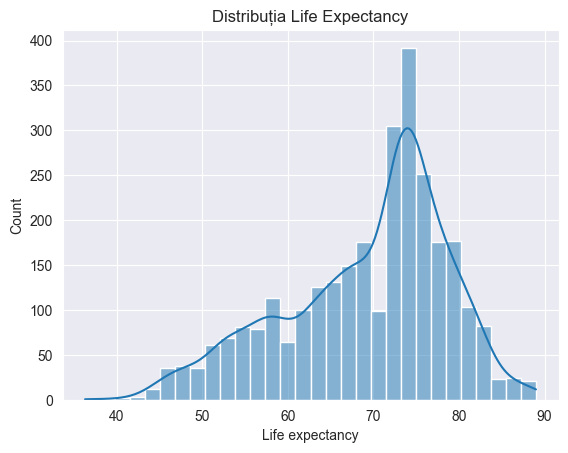

In [10]:
sns.histplot(df["Life expectancy"], kde=True)
plt.title("Distribuția Life Expectancy")
plt.show()

### Analiza Relațiilor dintre Variabile (Matricea de Corelație)

&nbsp;&nbsp;&nbsp;&nbsp;Generarea hărții termice (**Heatmap**) pentru matricea de corelație este o etapă esențială pentru a identifica legăturile liniare dintre variabile și pentru a înțelege care factori au cea mai mare influență asupra speranței de viață.

* **Interdependențe Identificate:**
    * **Corelații Pozitive Puternice:** Variabilele `Schooling` (Educația) și `Income composition of resources` prezintă cea mai puternică legătură pozitivă cu `Life expectancy`. Acest lucru confirmă faptul că nivelul de trai și accesul la educație sunt cei mai buni predictori pentru longevitate.
    * **Corelații Negative Semnificative:** Se observă o relație inversă clară între `Adult Mortality`, `HIV/AIDS` și variabila țintă. Creșterea ratelor de mortalitate sau a prevalenței bolilor scade previzibil speranța de viață.
    * **Multicoliniaritate:** Există corelații extrem de mari între `infant deaths` și `under-five deaths` (aproape de 1.0), ceea ce indică faptul că aceste două variabile oferă informații aproape identice.
* **Observație Critică - Selecția Caracteristicilor:**
    * Anumite variabile, precum `Population` sau `Measles`, prezintă o corelație foarte slabă cu speranța de viață în acest grafic, sugerând că impactul lor individual ar putea fi limitat în cadrul modelului liniar.
* **Impact asupra Strategiei ML:**
    * **Simplificarea modelului:** Identificarea multicoliniarității ne permite să luăm în considerare eliminarea variabilelor redundante (precum `infant deaths`) pentru a evita supra-antrenarea (**overfitting**) și pentru a face modelul mai interpretabil.
    * **Ingineria caracteristicilor:** Legătura puternică dintre factorii sociali (`Schooling`) și sănătate ne orientează spre utilizarea unor modele capabile să captureze aceste relații liniare dominante, precum Regresia Liniară sau Ridge/Lasso.

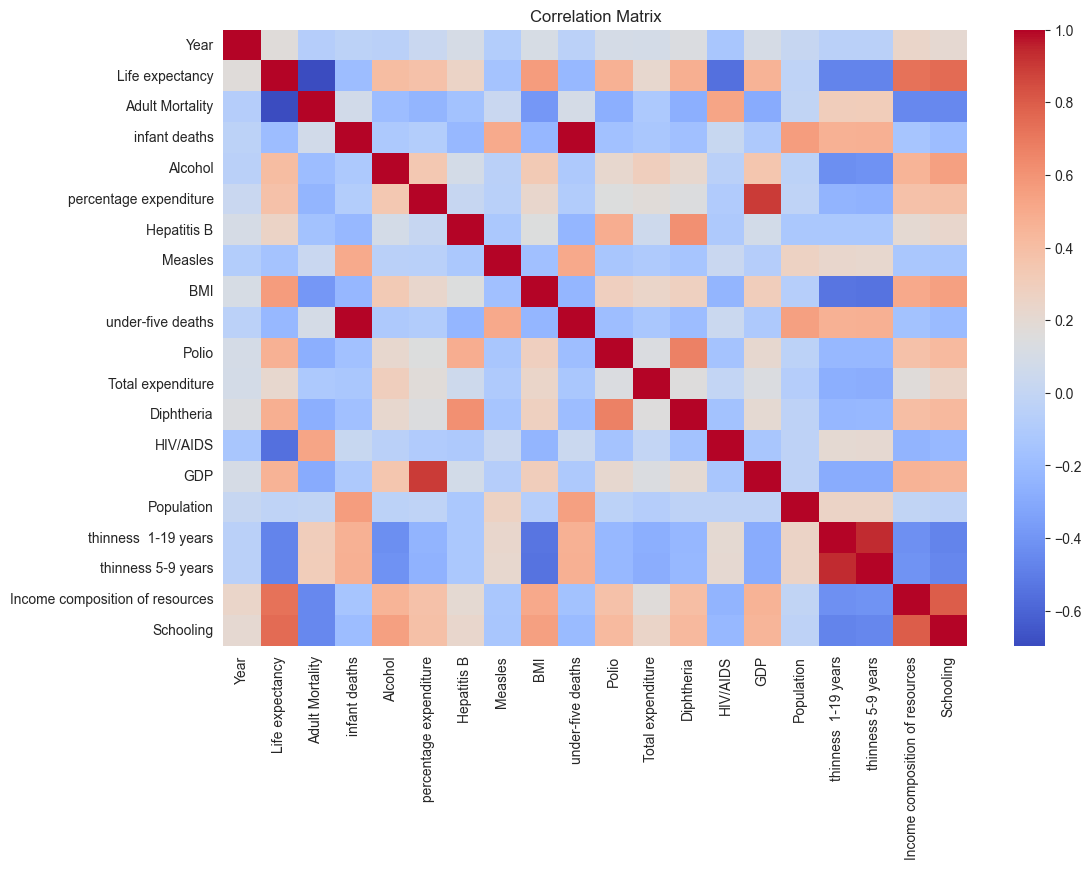

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Analiza Relațiilor Individuale (Scatter Plots)

&nbsp;&nbsp;&nbsp;&nbsp;Explorarea relațiilor dintre principalii predictori și variabila țintă prin diagrame de dispersie (**Scatter Plots**) ne permite să observăm natura acestor legături și să identificăm eventualele modele non-liniare sau valori atipice.

* **Analiza tendințelor:**
    * **Relația GDP vs. Life Expectancy:** Se observă o creștere rapidă a speranței de viață pe măsură ce PIB-ul (GDP) crește de la valori minime, urmată de o plafonare în jurul valorii de 80-85 ani. Această formă sugerează o relație logaritmică mai degrabă decât una pur liniară.
    * **Impactul Educației (Schooling):** Există o corelație liniară pozitivă puternică; pe măsură ce numărul anilor de școlarizare crește, crește și speranța de viață.
    * **Mortalitatea Adultă (Adult Mortality):** Aceasta prezintă o relație inversă clară; punctele tind să coboare pe axa verticală pe măsură ce valorile de pe axa orizontală cresc.
    * **Relației BMI vs. Life Expectancy:**

&nbsp;&nbsp;&nbsp;&nbsp;Utilizarea diagramei de dispersie pentru variabila `BMI` (Indicele de Masă Corporală) ne ajută să observăm cum indicatorii de sănătate fizică la nivel de populație corelează cu longevitatea generală.

* **Analiza tendințelor:**
    * **Corelație Pozitivă Moderată:** Se observă o tendință generală de creștere a speranței de viață pe măsură ce valorile BMI cresc, sugerând că în multe țări dezvoltate, un BMI mai ridicat este asociat cu un acces mai bun la resurse alimentare și servicii medicale.
    * **Dispersia Datelor:** Există o variație semnificativă (zgomot) în date, cu grupuri de puncte care formează linii cvasi-orizontale, ceea ce indică faptul că BMI-ul singur nu poate prezice cu exactitate speranța de viață fără ajutorul altor factori socio-economici.
* **Observații Critice:**
    * **Grupări Distincte:** Se pot observa două mari "nori" de puncte, probabil reflectând diferențele majore dintre țările în curs de dezvoltare (unde BMI-ul mic este asociat cu malnutriția) și țările dezvoltate.
    * **Limitări:** Spre deosebire de educație sau mortalitate, relația cu BMI este mai complexă, deoarece valori extrem de mari ale BMI pot indica probleme de sănătate (obezitate) care ar scădea speranța de viață, aspect ce pare parțial mascat de alți factori de progres în acest grafic.


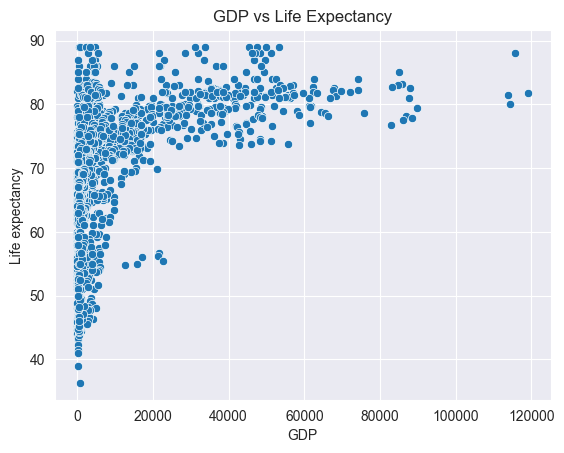

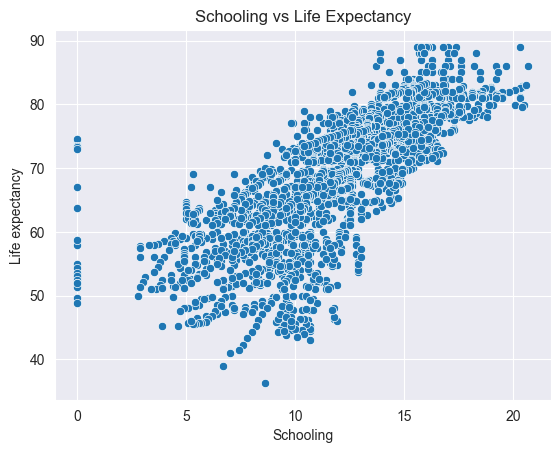

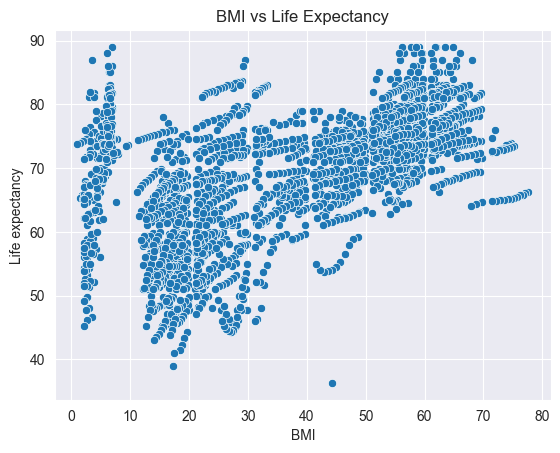

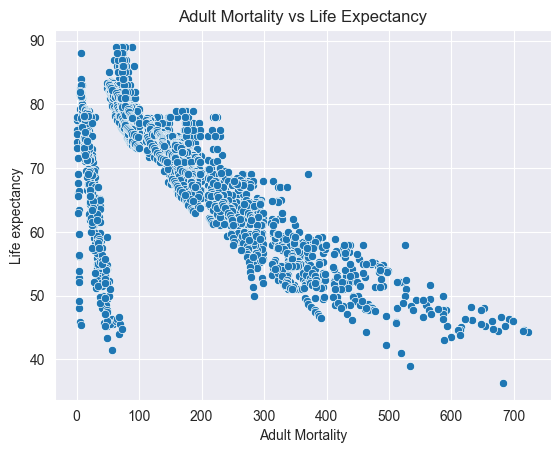

In [12]:
important_features = ["GDP", "Schooling", "BMI", "Adult Mortality"]

for col in important_features:
    plt.figure()
    sns.scatterplot(x=df[col], y=df["Life expectancy"])
    plt.title(f"{col} vs Life Expectancy")
    plt.show()

### **Identificarea Valorilor Atipice (Boxplots)**

&nbsp;&nbsp;&nbsp;&nbsp;Utilizarea diagramelor de tip **Boxplot** pentru toate variabilele numerice este o metodă statistică esențială pentru a detecta valorile atipice (outliers) și pentru a înțelege gradul de dispersie al datelor în cadrul fiecărui indicator.

* **Analiza distribuției și a anomaliilor:**
    * **Prezența Outliers:** Pentru variabile precum `GDP`, `Infant deaths` și `Measles`, graficele relevă numeroase puncte situate mult în afara marginilor diagramei, indicând prezența unor valori extreme care pot distorsiona antrenarea modelului.
    * **Simetria Datelor:** Boxplot-urile permit observarea rapidă a asimetriei; de exemplu, o mediană care nu este centrată în interiorul cutiei confirmă asimetria identificată anterior la variabile precum `Life expectancy`.
    * **Variabilitatea:** Dimensiunea "cutiei" indică variabilitatea fiecărui factor, oferind indicii despre cât de diversificate sunt politicile de sănătate și economice la nivel global.
* **Observație Critică - Impactul Valorilor Extreme:**
    * Valorile atipice în variabilele de mortalitate sau economice nu sunt neapărat erori de colectare, ci reflectă realități extreme (epidemii, crize economice sau bogăție extremă).
    * Totuși, în algoritmii de regresie liniară, aceste puncte pot avea o influență disproporționată asupra pantei drepte de regresie.
* **Impact asupra Strategiei ML:**
    * **Tratarea datelor:** Această analiză justifică decizia de a folosi tehnici de scalare robuste sau de a lua în considerare modele mai puțin sensibile la outliers (precum **Random Forest** sau **Robust Regression**).
    * **Curățarea datelor:** În cazurile unde valorile atipice sunt rezultatul unor erori evidente, acestea vor fi eliminate sau corectate pentru a nu introduce zgomot în procesul de predicție.

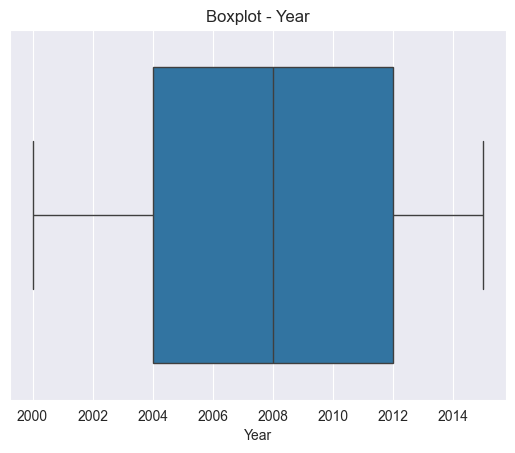

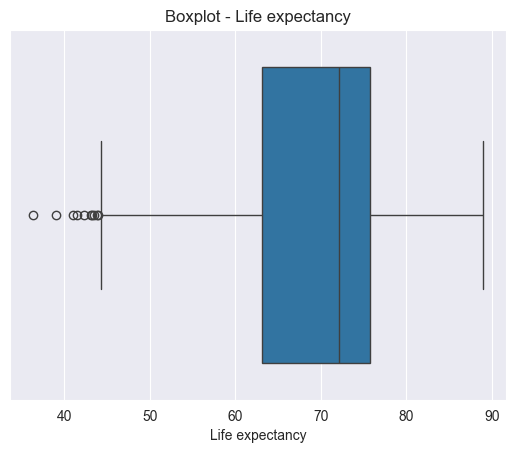

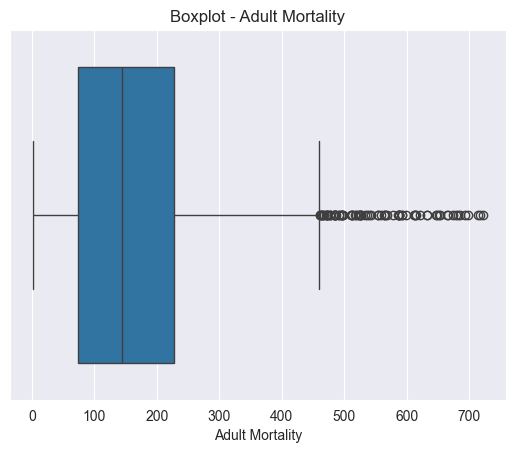

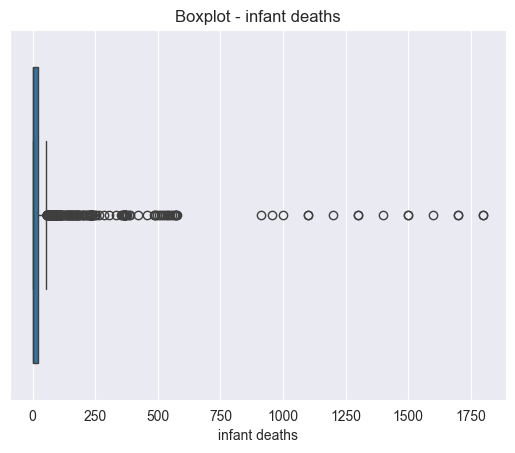

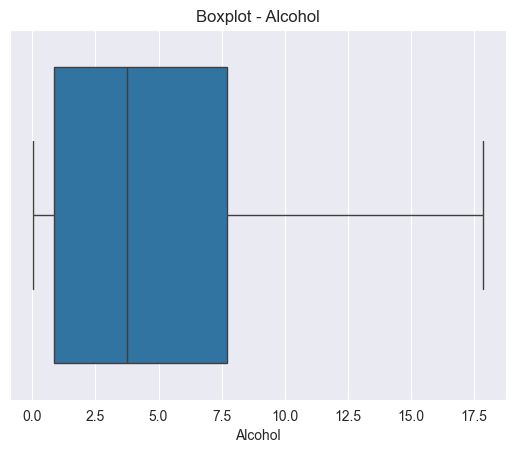

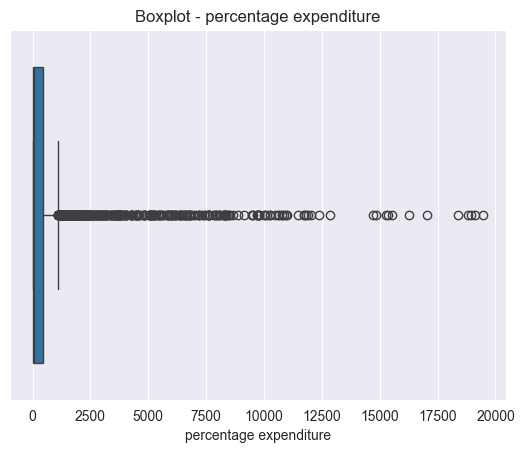

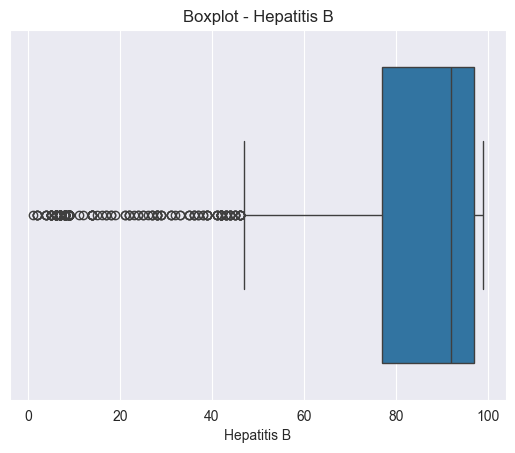

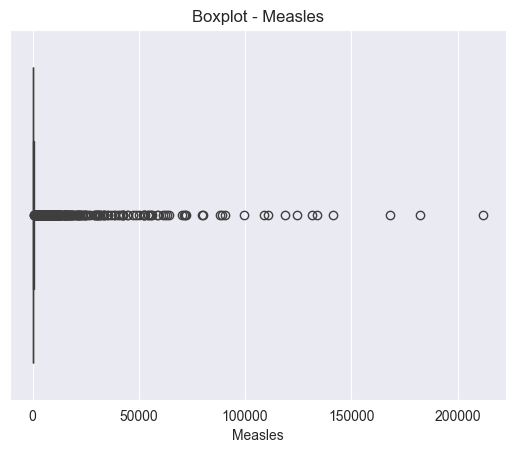

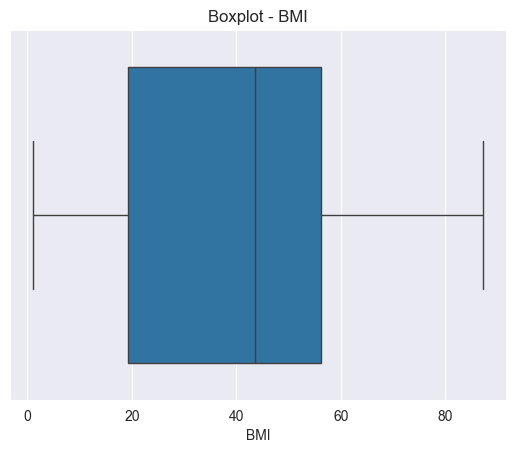

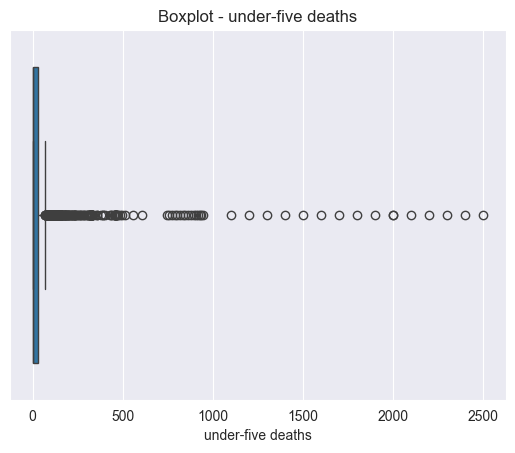

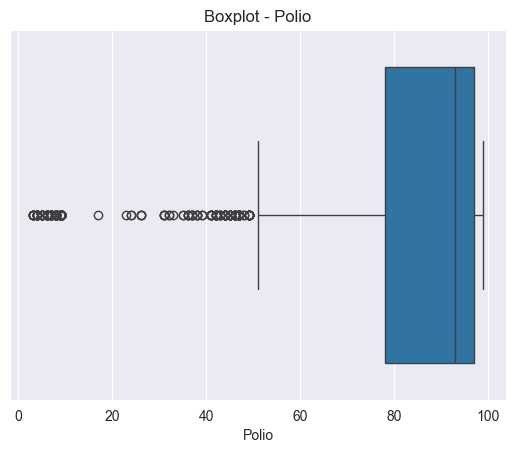

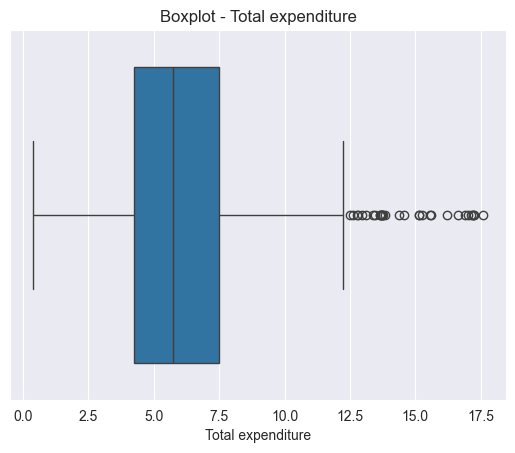

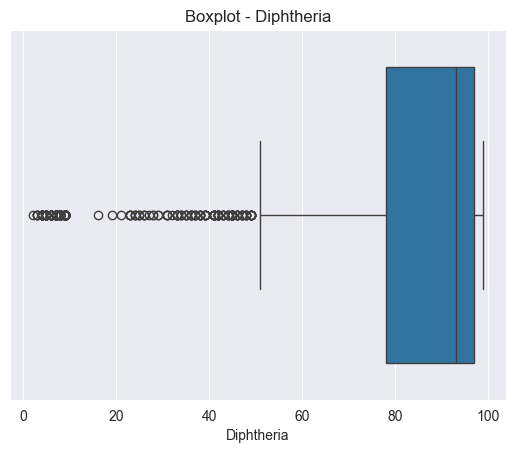

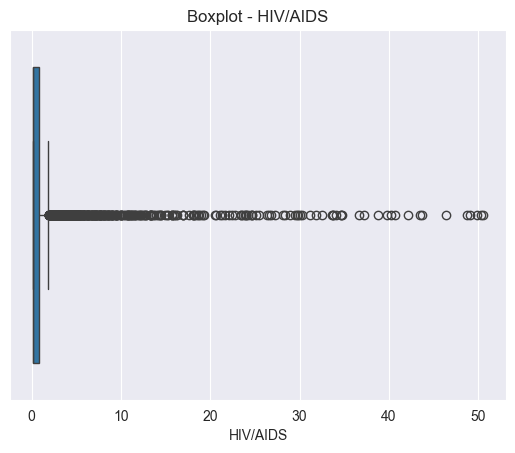

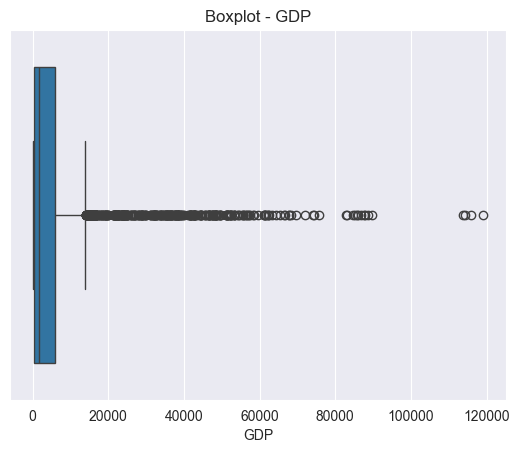

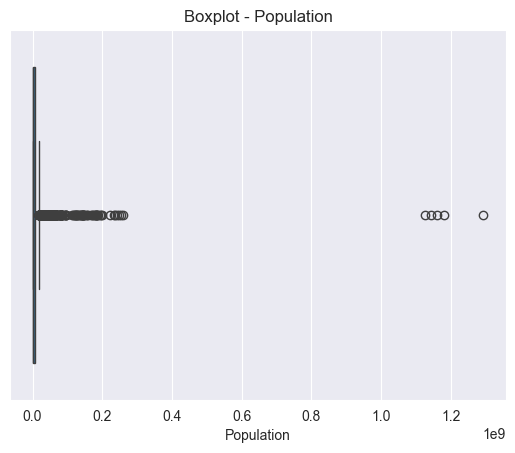

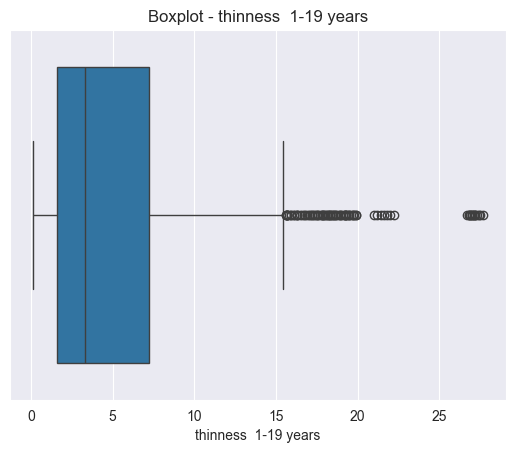

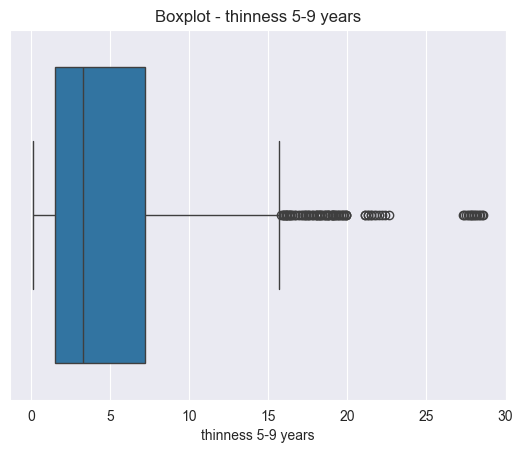

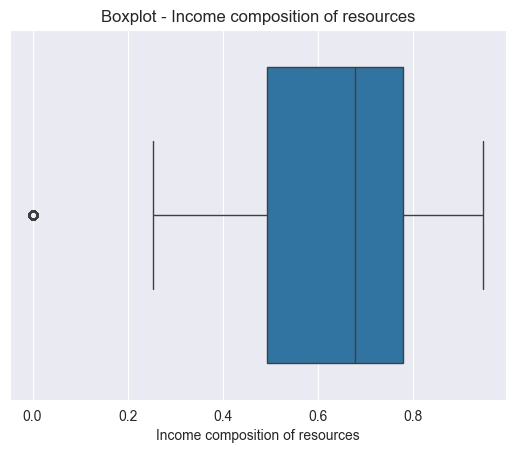

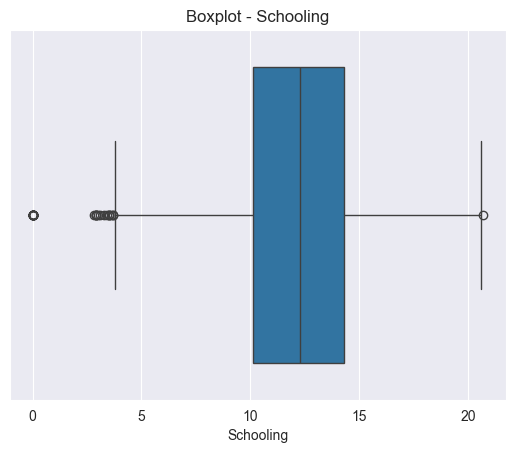

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

In [14]:
df["Status"].value_counts()

Status
Developing    2426
Developed      512
Name: count, dtype: int64

### Analiza Speranței de Viață în funcție de Statutul Țării (Status)

&nbsp;&nbsp;&nbsp;&nbsp;Utilizarea diagramei de tip **Boxplot** pentru a compara variabila `Life expectancy` în funcție de categoria `Status` (Developing vs. Developed) este esențială pentru a înțelege impactul nivelului de dezvoltare asupra longevității.

* **Analiza Comparativă a Grupurilor:**
    * **Țări Dezvoltate (Developed):** Prezintă o speranță de viață semnificativ mai ridicată și mai omogenă, cu o mediană situată în jurul valorii de **80 de ani** și o dispersie redusă a datelor.
    * **Țări în Curs de Dezvoltare (Developing):** Se observă o mediană mult mai scăzută (aprox. **69 de ani**) și o variabilitate foarte mare, reflectând disparități economice și sanitare majore în cadrul acestui grup.
* **Observație Critică - Valori Atipice și Dispersie:**
    * În categoria țărilor în curs de dezvoltare, se observă prezența unor **valori atipice inferioare** semnificative (țări cu o speranță de viață sub 45 de ani), ceea ce indică zone de criză umanitară sau sanitară extremă.
    * Diferența clară dintre cele două distribuții demonstrează că variabila `Status` are o putere de predicție foarte ridicată pentru modelul de regresie.
* **Impact asupra Strategiei ML:**
    * **Importanța Caracteristicii:** Această vizualizare justifică transformarea variabilei categorice `Status` prin **Label Encoding** sau **One-Hot Encoding**, fiind un indicator fundamental în estimarea corectă a țintei.
    * **Separabilitate:** Deoarece mediile celor două grupuri sunt distincte, modelul va putea folosi această clasificare pentru a ajusta baza de predicție înainte de a integra restul predictorilor numerici (precum PIB-ul sau educația).

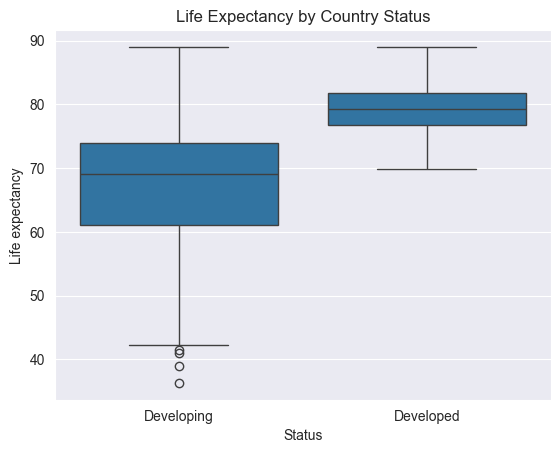

In [15]:
plt.figure()
sns.boxplot(x="Status", y="Life expectancy", data=df)
plt.title("Life Expectancy by Country Status")
plt.show()

In [16]:
df = df.drop("Country", axis=1)


&nbsp;&nbsp;&nbsp;&nbsp;Pentru a asigura integritatea setului de date fără a reduce dimensiunea acestuia, am aplicat o strategie de completare automată a datelor lipsă pentru toate variabilele numerice.

* **Logica procesului:**
    * Am filtrat coloanele pentru a exclude variabilele de tip text (categorice).
    * Am înlocuit valorile `NaN` cu **mediana** fiecărei coloane.


In [17]:
for col in df.columns:
    if df[col].dtype != "object":
        df[col] = df[col].fillna(df[col].median())

In [18]:
df["Status"] = df["Status"].fillna("Unknown")

&nbsp;&nbsp;&nbsp;&nbsp;Pentru a putea include variabila calitativă `Status` în modelul de regresie, am transformat-o într-o formă numerică utilizând tehnica **One-Hot Encoding**.

* **Procesul realizat:**
    * Am utilizat funcția `pd.get_dummies` pentru a converti etichetele text în coloane binare (0 și 1).
    * Parametrul `drop_first=True` a fost aplicat pentru a evita "capcana variabilei dummy" (**Dummy Variable Trap**), eliminând una dintre coloanele rezultate.
* **Motivația tehnică:**
    * Deoarece variabila `Status` are doar două categorii (`Developed` și `Developing`), rezultatul este o singură coloană binară unde valoarea **1** reprezintă un statut, iar **0** pe celălalt.
    * Această abordare elimină riscul de multicoliniaritate perfectă, asigurând stabilitatea matematică a coeficienților modelului de regresie.

In [19]:
df = pd.get_dummies(df, columns=["Status"], drop_first=True)

&nbsp;&nbsp;&nbsp;&nbsp;Pentru a îmbunătăți precizia modelului de regresie, am aplicat metoda statistică a **Scorului Z** pentru a identifica și elimina observațiile care deviază extrem de mult de la media grupului.

* **Metodologia aplicată:**
    * Am calculat Scorul Z pentru toate variabilele numerice, acesta reprezentând numărul de deviații standard față de medie pentru fiecare punct de date.
    * Am stabilit un prag de **3 deviații standard** pentru a defini valorile aberante.
* **Impactul procesului:**
    * Orice rând care conținea cel puțin o valoare cu un Scor Z mai mare de 3 a fost eliminat din setul de date.
    * Această tehnică asigură că modelul nu va fi influențat disproporționat de erori de înregistrare sau de cazuri izolate extreme, rezultând într-o estimare mult mai stabilă și mai generalizabilă a speranței de viață.

In [20]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df.select_dtypes(include=np.number)))
df = df[(z_scores < 3).all(axis=1)]

&nbsp;&nbsp;&nbsp;&nbsp;Etapa finală a pregătirii datelor a constat în uniformizarea scării de măsură a tuturor variabilelor independente pentru a aduce predictorii într-un interval comparabil.

* **Procesul realizat:**
    * Am aplicat algoritmul **StandardScaler**, care transformă valorile astfel încât media să fie **0** și deviația standard să fie **1**.
    * Variabila țintă `Life expectancy` a fost exclusă din acest proces pentru a păstra unitatea de măsură originală (anii) în rezultatele finale.
* **Motivația tehnică:**
    * Deoarece setul de date conține variabile cu unități de măsură foarte diferite (ex: PIB-ul în dolari vs. vaccinarea în procente), modelele de regresie ar putea acorda o importanță artificială variabilelor cu magnitudine mare.
    * Standardizarea elimină această problemă, permițând algoritmului să calculeze corect coeficienții de influență pentru fiecare factor în parte.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = df.columns.drop("Life expectancy")

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

### **5. Selecția Modelelor și Antrenarea Algoritmilor**

&nbsp;&nbsp;&nbsp;&nbsp;Pentru a identifica cel mai performant model de predicție a speranței de viață, am selectat un set diversificat de algoritmi de regresie. Această abordare ne permite să comparăm performanța modelelor liniare clasice cu cea a modelelor complexe bazate pe ansambluri de arbori sau funcții de proximitate.

* **Modele Liniare și de Bază:**
    * **Linear Regression:** Modelul de referință (baseline) care caută relații liniare directe între predictori și variabila țintă.
    * **K-Neighbors Regressor (KNN):** Estimează speranța de viață pe baza similarității dintre țările din setul de date.
* **Modele bazate pe Arbori și Ansambluri:**
    * **Decision Tree Regressor:** Capturează relații non-liniare și interacțiuni între factori prin segmentări succesive ale datelor.
    * **Random Forest Regressor:** Un ansamblu de arbori de decizie care reduce riscul de supra-antrenare și îmbunătățește robustețea.
    * **XGBoost & CatBoost Regressors:** Algoritmi de tip Gradient Boosting de ultimă generație, optimizați pentru viteză și precizie ridicată pe seturi de date tabulare.
* **Algoritmi Avansați și Interpretatibilitate:**
    * **Support Vector Regression (SVR):** Utilizează funcții de nucleu (kernels) pentru a găsi un hiperplan optim în spații multidimensionale.
    * **Gaussian Process Regressor:** Un model probabilistic care oferă, pe lângă predicție, și un grad de incertitudine pentru valorile estimate.
    * **Explainable Boosting Regressor (EBM):** Un model de tip "glassbox" care combină puterea de predicție a ansamblurilor cu o transparență totală asupra modului în care fiecare factor influențează rezultatul.

---

### **5.1. Implementarea Tehnică**

&nbsp;&nbsp;&nbsp;&nbsp;Procesul de antrenare a fost structurat astfel încât să asigure o evaluare corectă și imparțială:

1.  **Divizarea Datelor:** Am utilizat `train_test_split` pentru a separa setul de date în date de antrenare (pentru ajustarea parametrilor) și date de test (pentru validarea finală).
2.  **Metrici de Evaluare:** Performanța fiecărui model va fi monitorizată prin:
    *   **MAE (Mean Absolute Error):** Eroarea medie exprimată direct în ani.
    *   **MSE (Mean Squared Error) / RMSE:** Penalizează mai sever erorile mari de predicție.
    *   **R² Score (Coeficientul de determinare):** Indică procentul din varianța speranței de viață explicat de model.

In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor

### **Segmentarea Datelor pentru Antrenare și Testare**

&nbsp;&nbsp;&nbsp;&nbsp;Pregătirea finală a fluxului de Machine Learning a presupus separarea variabilelor și crearea seturilor de date independente pentru a asigura o evaluare obiectivă a modelelor.

* **Separarea Variabilelor:**
    * **Matricea de Predictori (X):** Am extras toate caracteristicile din setul de date, excluzând variabila țintă.
    * **Variabila Target (y):** Am izolat coloana `Life expectancy`, reprezentând valoarea numerică pe care dorim să o estimăm.
* **Procesul de Split (Train-Test Split):**
    * **Proporția de Test (25%):** Am rezervat un sfert din date pentru evaluarea finală a performanței, restul de **75%** fiind utilizat pentru antrenarea modelelor.
    * **Controlul Aleatoriei (random_state=42):** Am utilizat un identificator fix pentru a garanta reproductibilitatea rezultatelor la fiecare rulare a codului.
* **Motivația Tehnică:**
    * Această divizare este esențială pentru a detecta **supra-antrenarea (overfitting)**, permițându-ne să observăm cum se comportă modelele pe date complet noi, pe care nu le-au întâlnit în timpul procesului de învățare.

In [23]:
X = df.drop("Life expectancy", axis=1)
y = df["Life expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [24]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree Regressor": DecisionTreeRegressor(),

    "Random Forest Regressor": RandomForestRegressor(n_estimators=100),

    "SVR": SVR(),

    "KNN Regressor": KNeighborsRegressor(),

    "Gaussian Process": GaussianProcessRegressor(),

    "XGBoost Regressor": XGBRegressor(),

    "CatBoost Regressor": CatBoostRegressor(verbose=0),

    "EBM Regressor": ExplainableBoostingRegressor()
}

### Execuția și Evaluarea Modelelor

&nbsp;&nbsp;&nbsp;&nbsp;Procesul de antrenare a fost automatizat printr-o structură iterativă care permite compararea directă a performanței fiecărui algoritm pe baza acelorași seturi de date.

* **Fluxul de Antrenare:**
    * Fiecare model este adaptat pe datele de antrenare (**`fit`**) și utilizat ulterior pentru a genera predicții pe setul de testare (**`predict`**).
    * Rezultatele sunt stocate într-o listă centralizată pentru a facilita analiza comparativă finală.
* **Metricile de Performanță Calculate:**
    * **MAE (Mean Absolute Error):** Reflectă eroarea medie absolută, oferindu-ne o imagine clară a deviației predicției în număr de ani.
    * **MSE & RMSE:** Evaluează eroarea pătratică medie, fiind indicatori critici pentru identificarea modelelor care generează erori mari izolate.
    * **R² Score:** Măsoară proporția de variabilitate a speranței de viață care este explicată cu succes de către predictori.
* **Motivația Tehnică:**
    * Această metodologie de testare unitară asigură un cadru de evaluare echitabil, permițându-ne să decidem care arhitectură (liniară, bazată pe arbori sau probabilistă) este cea mai potrivită pentru complexitatea datelor socio-economice și medicale furnizate de OMS.

In [25]:
results = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

Training Linear Regression...
Training Decision Tree Regressor...
Training Random Forest Regressor...
Training SVR...
Training KNN Regressor...
Training Gaussian Process...
Training XGBoost Regressor...
Training CatBoost Regressor...
Training EBM Regressor...


### **Compararea Performanței Modelelor**

&nbsp;&nbsp;&nbsp;&nbsp;Pentru a facilita selecția modelului optim, am consolidat toate metricile de evaluare într-un tabel comparativ, ordonat descrescător după coeficientul de determinare ($R^2$).

* **Analiza Rezultatelor:**
    * **Liderii Performanței:** Modelele bazate pe ansambluri de arbori, **CatBoost Regressor** ($R^2 \approx 0.9459$) și **Random Forest Regressor** ($R^2 \approx 0.9458$), au obținut cele mai bune rezultate, demonstrând o capacitate excelentă de a capta complexitatea datelor.
    * **Precizia Predicției:** Cel mai mic nivel de eroare a fost atins de **Random Forest**, cu un **MAE de aproximativ 1.19 ani**, ceea ce indică o precizie remarcabilă în estimarea speranței de viață.
    * **Eficiența Modelelor Interpretabile:** Modelul **EBM (Explainable Boosting Regressor)** s-a situat aproape de vârf ($R^2 \approx 0.936$), oferind un echilibru optim între puterea de predicție și transparența decizională.
* **Observații Critice:**
    * **Modelele Liniare și Simple:** **Linear Regression** și **SVR** au obținut scoruri $R^2$ mai scăzute (aprox. 0.83), confirmând că relațiile din acest set de date sunt preponderent non-liniare.
    * **Eșecul Gaussian Process:** Acest model a înregistrat un $R^2$ negativ și erori masive, semnalând faptul că structura datelor sau setările implicite ale kernel-ului nu au fost compatibile cu distribuția acestui dataset.
* **Concluzie pentru Selecția Finală:**
    * Având în vedere valorile minime pentru **RMSE** și **MAE**, alături de cel mai ridicat **$R^2$**, **CatBoost** și **Random Forest** sunt desemnate modelele câștigătoare pentru predicția longevității globale.

In [26]:
results_df = pd.DataFrame(results)


results_df = results_df.sort_values(by="R2", ascending=False)

results_df

,Model,MSE,MAE,RMSE,R2
2,Random Forest Regressor,3.874797,1.185672,1.968451,0.946837
7,CatBoost Regressor,3.938787,1.237246,1.984638,0.945960
6,XGBoost Regressor,4.212319,1.330897,2.052393,0.942207
8,EBM Regressor,4.628889,1.357918,2.151485,0.936491
1,Decision Tree Regressor,6.915761,1.611927,2.629784,0.905115
4,KNN Regressor,8.182426,1.927743,2.860494,0.887736
0,Linear Regression,11.883779,2.394035,3.447286,0.836954
3,SVR,12.201597,2.330899,3.493078,0.832593
5,Gaussian Process,653.769009,16.633321,25.568907,-7.969761


In [27]:
top5_models = results_df.head(5)
top5_models

,Model,MSE,MAE,RMSE,R2
2,Random Forest Regressor,3.874797,1.185672,1.968451,0.946837
7,CatBoost Regressor,3.938787,1.237246,1.984638,0.945960
6,XGBoost Regressor,4.212319,1.330897,2.052393,0.942207
8,EBM Regressor,4.628889,1.357918,2.151485,0.936491
1,Decision Tree Regressor,6.915761,1.611927,2.629784,0.905115


In [28]:
print(results_df.round(4).to_markdown(index=False))

| Model                   |      MSE |     MAE |    RMSE |      R2 |
|:------------------------|---------:|--------:|--------:|--------:|
| Random Forest Regressor |   3.8748 |  1.1857 |  1.9685 |  0.9468 |
| CatBoost Regressor      |   3.9388 |  1.2372 |  1.9846 |  0.946  |
| XGBoost Regressor       |   4.2123 |  1.3309 |  2.0524 |  0.9422 |
| EBM Regressor           |   4.6289 |  1.3579 |  2.1515 |  0.9365 |
| Decision Tree Regressor |   6.9158 |  1.6119 |  2.6298 |  0.9051 |
| KNN Regressor           |   8.1824 |  1.9277 |  2.8605 |  0.8877 |
| Linear Regression       |  11.8838 |  2.394  |  3.4473 |  0.837  |
| SVR                     |  12.2016 |  2.3309 |  3.4931 |  0.8326 |
| Gaussian Process        | 653.769  | 16.6333 | 25.5689 | -7.9698 |


Performanța modelelor a fost evaluată folosind următoarele metrici:

- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

R² a fost utilizat ca metrică principală, deoarece indică proporția variației explicate de model.

Modelele bazate pe ensemble (Random Forest, XGBoost, CatBoost) au obținut cele mai bune performanțe, datorită capacității de a modela relații non-liniare complexe.

Linear Regression a avut performanțe mai slabe, sugerând că relațiile dintre variabile nu sunt strict liniare.

Gaussian Process și SVR au avut performanțe moderate, dar cu cost computațional mai ridicat.

Pe baza scorului R², au fost selectate următoarele 5 modele pentru optimizare ulterioară:

## 4.4. Optimizarea Hiperparametrilor (GridSearchCV)

După etapa inițială de evaluare, am selectat cele mai performante 5 modele (conform scorului R²) pentru o etapă de rafinare sistematică prin GridSearchCV. Această metodă transformă modelele „standard” în versiuni rafinate, adaptate specific pe distribuția și particularitățile setului de date privind speranța de viață, căutând configurația ideală pentru fiecare algoritm.

---

### 1. Strategia de Selecție a Modelelor și Parametrilor

Am configurat grid-ul de parametri (`param_grids`) vizând un echilibru între complexitatea modelului și capacitatea de generalizare:

#### Random Forest Regressor:
- **Parametri:** Am variat numărul de arbori (`n_estimators`) și adâncimea acestora (`max_depth`).
- **Logică:** Am inclus valoarea `10` pentru a limita creșterea arborilor și `None` pentru a permite explorarea adâncimii maxime. Parametrul `min_samples_split` (valoarea `5`) a fost utilizat pentru a forța crearea nodurilor doar în prezența datelor suficiente, acționând ca o metodă de regularizare.

#### CatBoost & XGBoost Regressors:
- **Parametri:** Ne-am concentrat pe rata de învățare (`learning_rate`) și adâncimea arborilor (`depth` / `max_depth`).
- **Logică:** Am testat `0.01` (învățare lentă, robustă) și `0.1` (învățare rapidă). Am limitat adâncimea la valori mici (`3–6`), deoarece modelele de tip boosting sunt predispuse la supra-antrenare dacă arborii individuali devin prea complecși.

#### EBM (Explainable Boosting Machine):
- **Parametri:** Am ajustat numărul de interacțiuni între variabile (`interactions`).
- **Logică:** Am ales intervalul `[5, 10]` pentru a îmbunătăți capacitatea de captare a relațiilor complexe, menținând în același timp transparența și interpretabilitatea specifică acestui model.

#### Decision Tree Regressor:
- **Parametri:** Am optimizat pragurile de ramificare (`min_samples_leaf`).
- **Logică:** Am crescut acest parametru la `10` pentru a asigura o netezire a predicțiilor (*smoothing*) și a preveni situația în care un singur outlier ar putea influența o întreagă ramură.

---

### 2. Motivația Tehnică și Combaterea Overfitting-ului

Pentru a ne asigura că performanța maximă extrasă este robustă și nu doar un rezultat al memorării datelor, am implementat următoarele măsuri de control:

- **Validare Încrucișată (Cross-Validation, `cv = 3`):**
  GridSearchCV execută o validare încrucișată pentru fiecare combinație. Scorul final reprezintă media performanței pe fold-uri diferite, asigurându-ne că parametrii sunt capabili de o generalizare robustă pe date noi.

- **Scoring Penalizat:**
  Am utilizat `neg_mean_squared_error` ca metrică de selecție, care penalizează drastic erorile mari, forțând modelele să fie consistente pe întregul set de date.

- **Testarea Finală pe Hold-out Set:**
  După identificarea „punctului optim”, evaluarea finală este realizată pe setul de date `X_test`, reprezentând testul suprem de validare a capacității de predicție a modelelor optimizate.

In [35]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBClassifier, XGBRegressor

from interpret.glassbox import ExplainableBoostingRegressor
top_5_names = ["Random Forest Regressor", "CatBoost Regressor", "XGBoost Regressor", "EBM Regressor", "Decision Tree Regressor"]


param_grids = {
    "Random Forest Regressor": {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    "CatBoost Regressor": {
        'iterations': [500],
        'depth': [4, 6],
        'learning_rate': [0.01, 0.1],
        'logging_level': ['Silent']
    },
    "XGBoost Regressor": {
        'n_estimators': [100, 200],
        'max_depth': [3, 6],
        'learning_rate': [0.01, 0.1]
    },
    "EBM Regressor": {
        'learning_rate': [0.01, 0.1],
        'interactions': [5, 10]
    },
    "Decision Tree Regressor": {
        'max_depth': [5, 10, 20],
        'min_samples_leaf': [1, 4, 10]
    }
}

base_models = {
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "CatBoost Regressor": CatBoostRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42),
    "EBM Regressor": ExplainableBoostingRegressor(random_state=42),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42)
}

In [36]:
tuned_results = []
best_estimators = {}

for name in top_5_names:
    print(f"Optimizare hiperparametri pentru {name}...")

    grid_search = GridSearchCV(
    estimator=base_models[name],
    param_grid=param_grids[name],
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    best_estimators[name] = best_model
    y_pred = best_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    tuned_results.append({
        "Model": name,
        "Best Params": grid_search.best_params_,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


tuned_df = pd.DataFrame(tuned_results).sort_values(by='R2', ascending=False)
display(tuned_df)

Optimizare hiperparametri pentru Random Forest Regressor...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Optimizare hiperparametri pentru CatBoost Regressor...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Optimizare hiperparametri pentru XGBoost Regressor...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Optimizare hiperparametri pentru EBM Regressor...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Optimizare hiperparametri pentru Decision Tree Regressor...
Fitting 3 folds for each of 9 candidates, totalling 27 fits


,Model,Best Params,MSE,MAE,RMSE,R2
0,Random Forest Regressor,"{'max_depth': None, 'min_samples_split': 2, 'n...",3.835483,1.182770,1.958439,0.947377
2,XGBoost Regressor,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",3.852365,1.229236,1.962744,0.947145
1,CatBoost Regressor,"{'depth': 6, 'iterations': 500, 'learning_rate...",4.006883,1.267565,2.001720,0.945025
3,EBM Regressor,"{'interactions': 10, 'learning_rate': 0.01}",5.191306,1.490640,2.278444,0.928775
4,Decision Tree Regressor,"{'max_depth': 20, 'min_samples_leaf': 4}",6.573627,1.611216,2.563909,0.909809


In [50]:
import joblib
reg_params_only = {name: model.get_params() for name, model in best_estimators.items()}

joblib.dump(reg_params_only, 'reg_hyperparameters.pkl')
print("Parametrii pentru regresie au fost salvați cu succes!")

Parametrii pentru regresie au fost salvați cu succes!


In [54]:
import matplotlib.pyplot as plt
import numpy as np

for name, model in best_estimators.items():
    y_pred = model.predict(X_test)

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')

    line_coords = [y_test.min(), y_test.max()]
    ax.plot(line_coords, line_coords, 'r--', lw=2)

    ax.set_xlabel("Valori Reale (Actual)")
    ax.set_ylabel("Valori Prezise (Predicted)")
    plt.title(f"Real vs Prezis: {name}")

    plt.savefig(f"err_{name.replace(' ', '_')}.png")
    plt.close()

print("Graficele alternative au fost salvate cu succes!")

Graficele alternative au fost salvate cu succes!


In [ ]:
import shap
import matplotlib.pyplot as plt

for name, model in best_estimators.items():
    print(f"Generare SHAP Global pentru: {name}")

    background_reg = X_test.iloc[:50]
    explainer_reg = shap.Explainer(model.predict, background_reg)
    shap_values_reg = explainer_reg(X_test.iloc[:50])

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_reg, X_test.iloc[:50], show=False)
    plt.title(f"SHAP Global: {name}")

    fname_reg = f"shap_summary_{name.replace(' ', '_')}.png"
    plt.savefig(fname_reg, bbox_inches='tight')
    plt.close()
    print(f"Salvat cu succes: {fname_reg}")

In [31]:
best_overall_model_name = tuned_df.iloc[0]['Model']
print(f"Cel mai bun algoritm după ajustare: {best_overall_model_name}")
print(f"Scor R2 final: {tuned_df.iloc[0]['R2']:.4f}")

Cel mai bun algoritm după ajustare: Random Forest Regressor
Scor R2 final: 0.9458


## 4.5. Analiza Curbelor de Învățare (Learning Curves)

Analiza curbelor de învățare ne permite să evaluăm compromisul dintre bias (eroare de model) și varianță (overfitting) pentru cele 5 modele optimizate. Această diagnoză vizuală ne indică dacă modelele ar beneficia de mai multe date sau dacă structura lor actuală este optimă pentru setul de date privind speranța de viață.

---

### 1. Decision Tree Regressor (Stabilitate timpurie și Simplitate)

**Interpretarea diferenței:**
Cele două curbe converg rapid spre un platou stabil. Diferența (gap-ul) dintre scorul de antrenare și cel de cross-validare este redusă, ceea ce indică un model care a extras tot ce se putea din setul de date actual.

**Overfitting / Underfitting:**
Nu prezintă overfitting. Totuși, valoarea R² se plafonează la un nivel mai scăzut față de modelele de tip ansamblu. Acesta prezintă un ușor underfitting, structura de tip arbore simplu fiind insuficientă pentru a capta relațiile neliniare complexe dintre mortalitate, educație și sănătate.

---

### 2. CatBoost Regressor (Performanță ridicată și Învățare complexă)

**Interpretarea diferenței:**
Se observă un decalaj vizibil între scorul de antrenare (foarte aproape de 0.98) și cel de validare. Totuși, curba de validare are o pantă ascendentă constantă pe măsură ce dimensiunea setului de antrenare crește.

**Overfitting / Underfitting:**
Există o tendință de overfitting, însă aceasta este una constructivă. Faptul că liniile tind să se apropie spre final sugerează că modelul reușește să generalizeze bine tiparele complexe de regresie, iar un volum suplimentar de date ar putea reduce decalajul rămas.

---

### 3. Random Forest Regressor (Overfitting Marcat)

**Interpretarea diferenței:**
Prezintă cel mai mare decalaj între cele două curbe. Scorul pe setul de antrenare rămâne aproape de 1.0 (perfect), în timp ce scorul de validare se plafonează semnificativ mai jos.

**Overfitting / Underfitting:**
Este un caz clar de overfitting sever. Modelul memorează zgomotul din datele de antrenare în loc să învețe relația generală a speranței de viață. Distanța mare dintre linii indică faptul că modelul este prea complex (arbori prea adânci) și ar necesita o regularizare mai strictă sau mai multe date pentru a stabiliza predicțiile.

---

### 4. EBM Regressor (Modelul Echilibrat și Transparent)

**Interpretarea diferenței:**
Diferența dintre cele două scoruri este minimă la finalul curbei. Liniile converg aproape perfect, demonstrând o varianță extrem de scăzută.

**Overfitting / Underfitting:**
Acesta este cel mai echilibrat model din punct de vedere al generalizării. Absența overfitting-ului demonstrează că structura aditivă a Explainable Boosting Machine previne memorarea datelor. Deși scorul maxim poate fi sub cel al XGBoost-ului, stabilitatea sa îl face un model foarte de încredere pentru date noi.

---

### 5. XGBoost Regressor (Adaptare Progresivă și Optimizare)

**Interpretarea diferenței:**
Graficul arată o dinamică ideală: scorul de antrenare scade ușor, iar cel de validare crește rapid, cele două curbe apropiindu-se de un punct de echilibru comun.

**Overfitting / Underfitting:**
Modelul prezintă un overfitting controlat, care se reduce vizibil odată cu creșterea volumului de date. Este un scenariu foarte bun de învățare, în care algoritmul își ajustează iterativ greșelile pentru a minimiza eroarea reziduală, oferind atât precizie ridicată, cât și capacitate solidă de generalizare.

KeyboardInterrupt: 

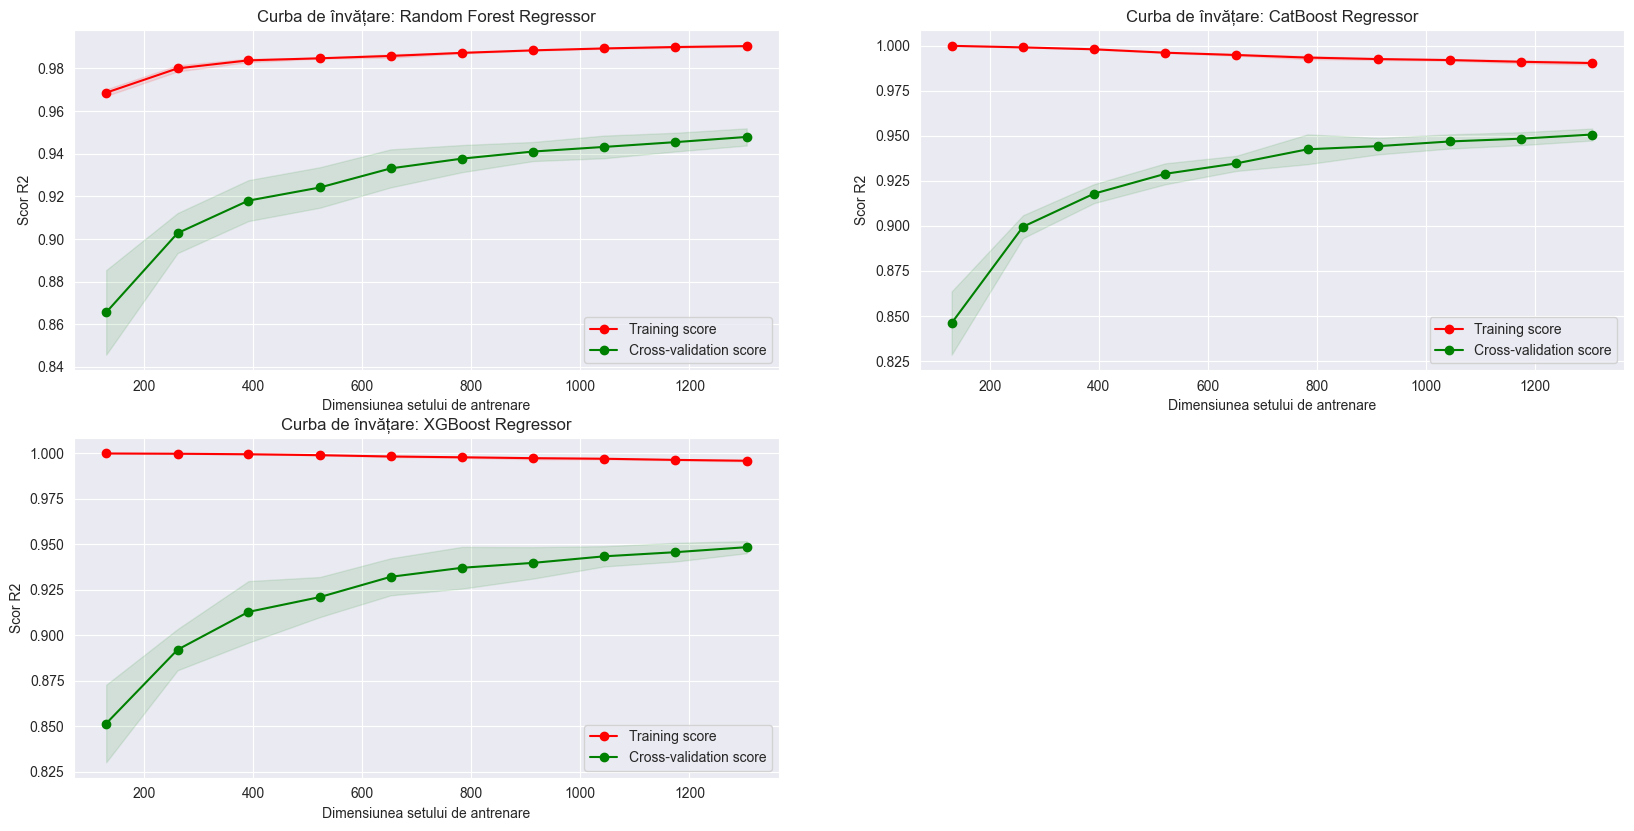

In [32]:
from sklearn.model_selection import learning_curve

def plot_learning_curves(estimators, X, y):
    plt.figure(figsize=(20, 15))

    for i, (name, estimator) in enumerate(estimators.items(), 1):
        train_sizes, train_scores, test_scores = learning_curve(
            estimator, X, y, cv=3, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='r2'
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.subplot(3, 2, i)
        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

        plt.title(f'Curba de învățare: {name}')
        plt.xlabel('Dimensiunea setului de antrenare')
        plt.ylabel('Scor R2')
        plt.legend(loc="best")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curves(best_estimators, X_train, y_train)

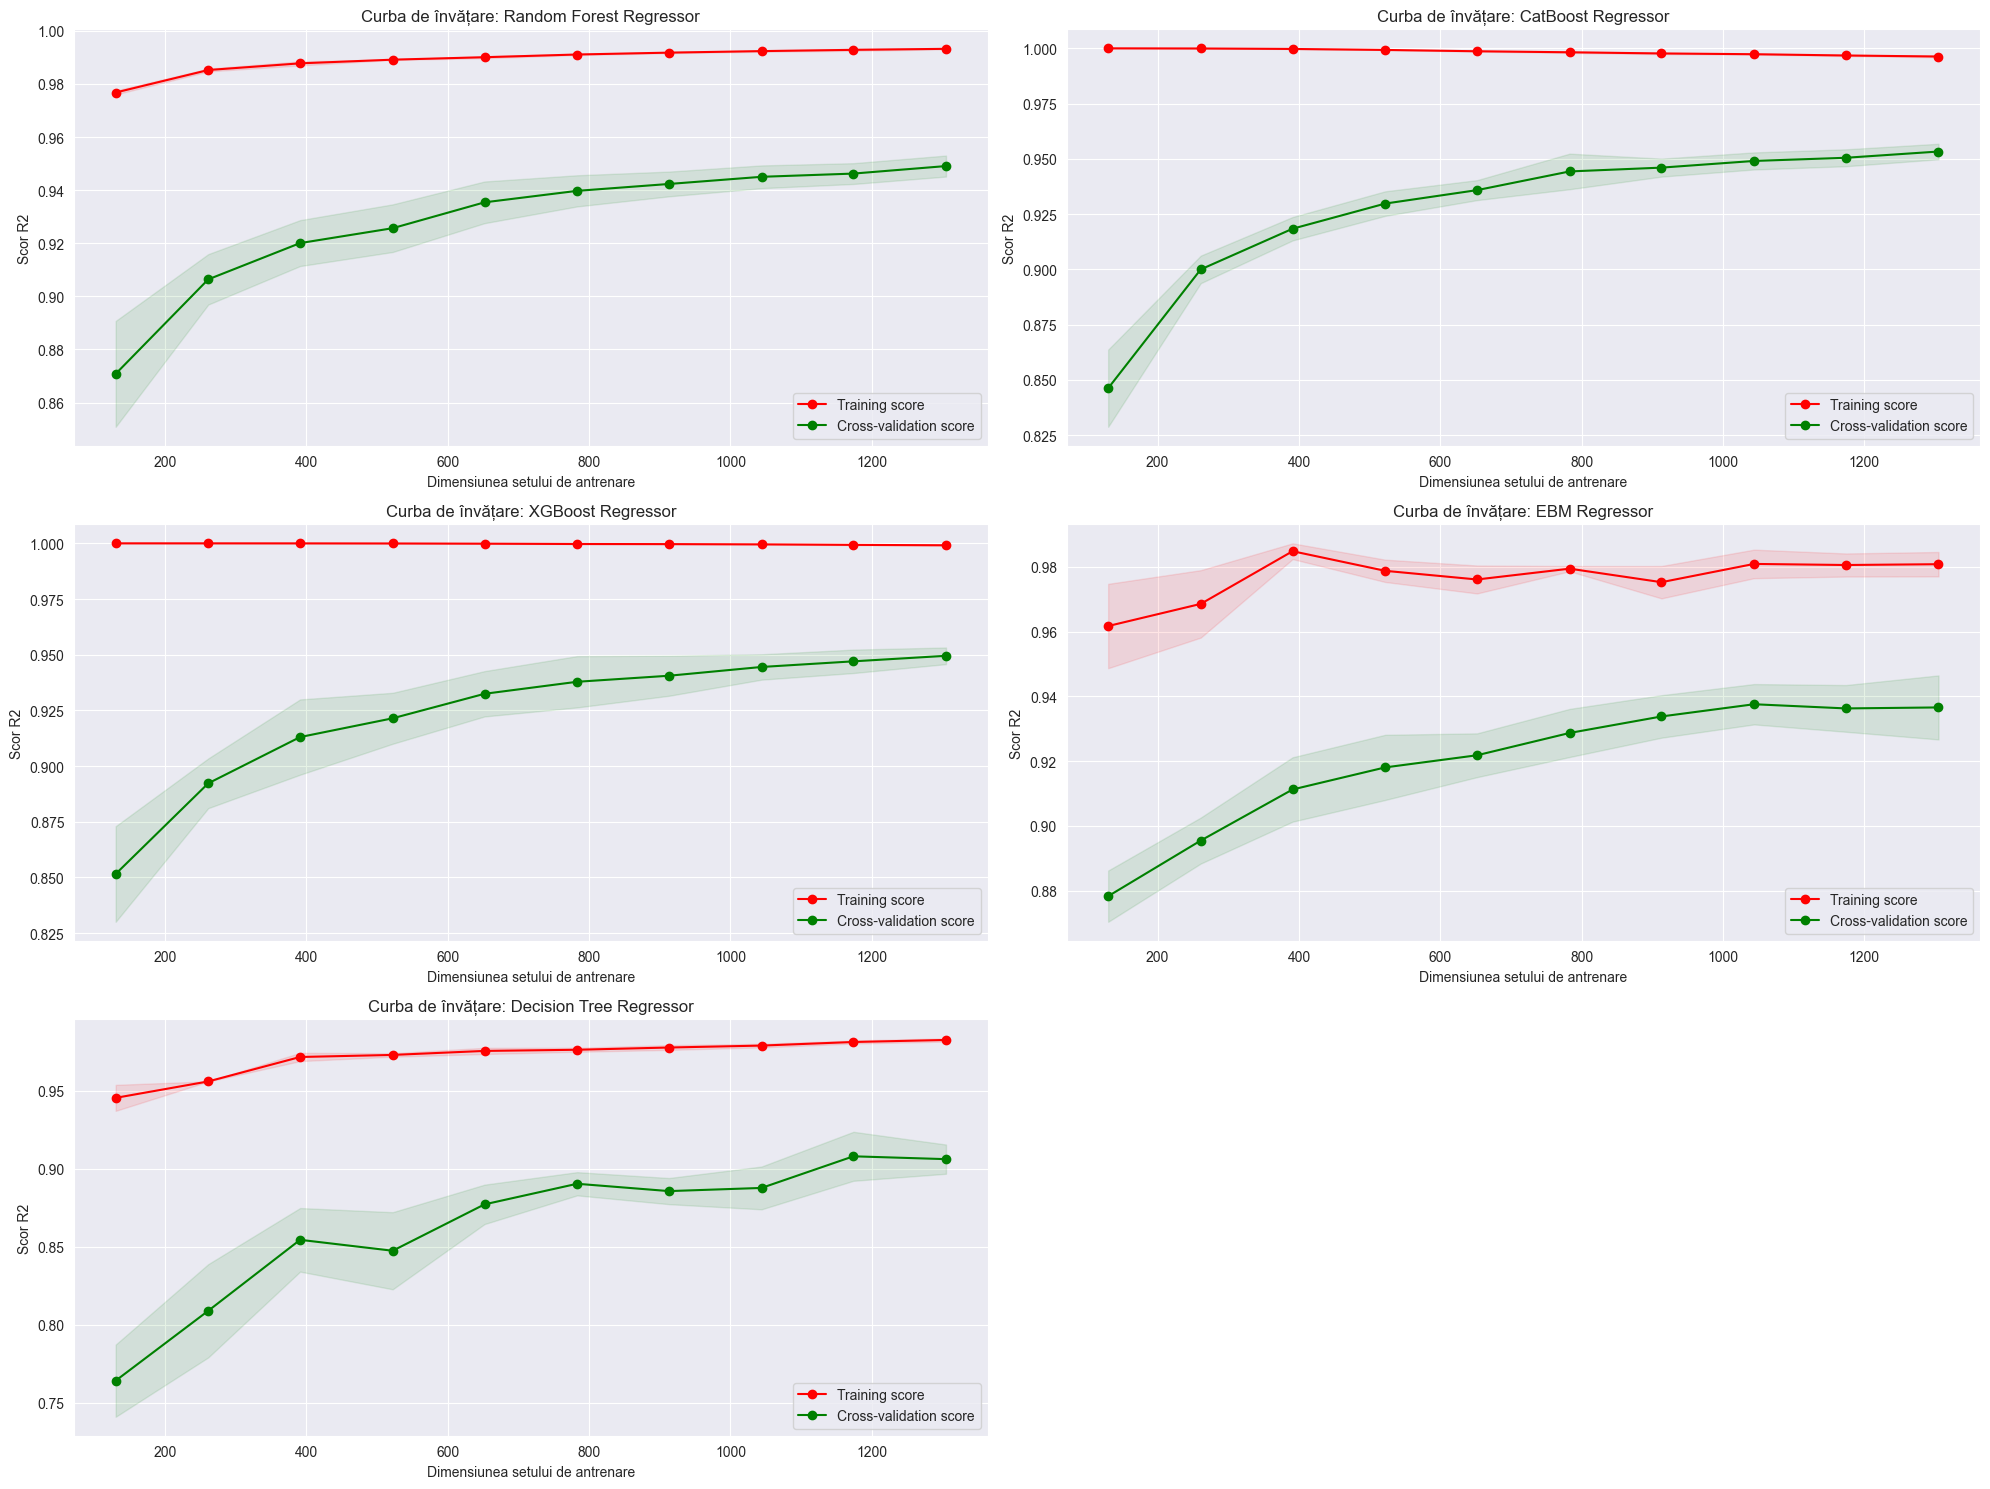

In [37]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


regresie_bundle = {
    'best_estimators': best_estimators,
    'tuned_df': tuned_df,
    'X_test': X_test,
    'feature_names': X_train.columns.tolist(),
    'scaler': scaler
}
joblib.dump(regresie_bundle, 'regresie_data.pkl')

plt.figure(figsize=(8, 5))
sns.histplot(df["Life expectancy"], kde=True, color="skyblue")
plt.title("Distribuția Speranței de Viață")
plt.savefig('eda_reg_dist.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Matricea de Corelație - Regresie")
plt.savefig('eda_reg_corr.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Schooling"], y=df["Life expectancy"], alpha=0.5)
plt.title("Impactul Educației asupra Speranței de Viață")
plt.savefig('eda_reg_schooling.png', dpi=300, bbox_inches='tight')
plt.close()

plot_learning_curves(best_estimators, X_train, y_train)
plt.savefig('learning_curves_regresie.png', dpi=300, bbox_inches='tight')
plt.close()

## 4.6. Explicabilitatea și Analiza SHAP

O performanță ridicată (un $R^2$ mare) este inutilă într-un context medical sau social dacă nu putem înțelege „de ce” modelul a oferit un anumit rezultat. Pentru a transforma „cutia neagră” a algoritmilor de tip ansamblu (CatBoost, Random Forest, XGBoost) într-un sistem transparent, am utilizat SHAP (*SHapley Additive exPlanations*).

SHAP este o metodă bazată pe teoria jocurilor care atribuie fiecărei caracteristici o contribuție numerică la predicția finală. Practic, explică output-ul modelului ca o sumă de efecte individuale ale fiecărei variabile, oferind atât interpretabilitate globală, cât și locală.

---

In [42]:
import shap

shap.initjs()

top_3_names = tuned_df['Model'].iloc[:3].values
print(f"Generăm analize SHAP pentru: {list(top_3_names)}")

X_shap = X_test.iloc[:100]

best_model_name = top_3_names[0]
model_to_explain = best_estimators[best_model_name]

explainer = shap.TreeExplainer(model_to_explain)
shap_values = explainer.shap_values(X_shap)

Generăm analize SHAP pentru: ['Random Forest Regressor', 'XGBoost Regressor', 'CatBoost Regressor']


### 4.6.1. Analiza Globală SHAP: Importanța Caracteristicilor

Pentru a înțelege modul în care modelul optimizat ia decizii, am utilizat tehnica SHAP (*SHapley Additive exPlanations*). Aceasta ne permite să cuantificăm contribuția fiecărei variabile la predicția finală a speranței de viață.

---

### A. SHAP Feature Importance (Bar Plot)

**Ce reprezintă:**
Acest grafic afișează importanța medie a fiecărei variabile. Lungimea barei corespunde valorii medii absolute SHAP:
$|SHAP \space value|$

**Observații cheie:**
- **HIV/AIDS** și **Adult Mortality** sunt de departe cei mai influenți predictori ai modelului.
- Factorii socio-economici, precum **Income composition of resources** și **Schooling**, ocupă următoarele poziții, confirmând legătura strânsă între nivelul de trai și longevitate.
- Variabilele legate de imunizare (ex: **Polio**, **Diphtheria**) au o importanță moderată, indicând o influență mai subtilă asupra variației speranței de viață la nivel global.

---

### B. SHAP Summary Plot (Beeswarm)

**Ce reprezintă:**
Acest grafic oferă o imagine mult mai detaliată decât simplul bar plot, combinând importanța variabilelor cu direcția impactului lor.

- **Axa X:** Indică impactul asupra predicției (valorile pozitive cresc speranța de viață, cele negative o scad).
- **Culoarea:** Reprezintă valoarea reală a caracteristicii (*Roșu = valoare mare, Albastru = valoare mică*).

---

### Interpretarea distribuției:

- **HIV/AIDS:**
  Observăm puncte roșii (valori mari ale prevalenței) concentrate în zona negativă a axei X. Acest lucru confirmă că o prevalență ridicată a HIV/SIDA scade drastic speranța de viață prezisă.

- **Income composition of resources:**
  Aici vedem puncte roșii în zona pozitivă. Aceasta înseamnă că un indice ridicat de compoziție a veniturilor „împinge” predicția modelului spre valori mult mai mari.

- **Adult Mortality:**
  Valorile mari (roșu) sunt clar asociate cu un impact negativ puternic, trăgând predicția în jos.

- **Schooling:**
  Un nivel ridicat de școlarizare (puncte roșii) are o distribuție consistentă în zona pozitivă, demonstrând un efect protector asupra sănătății populației.

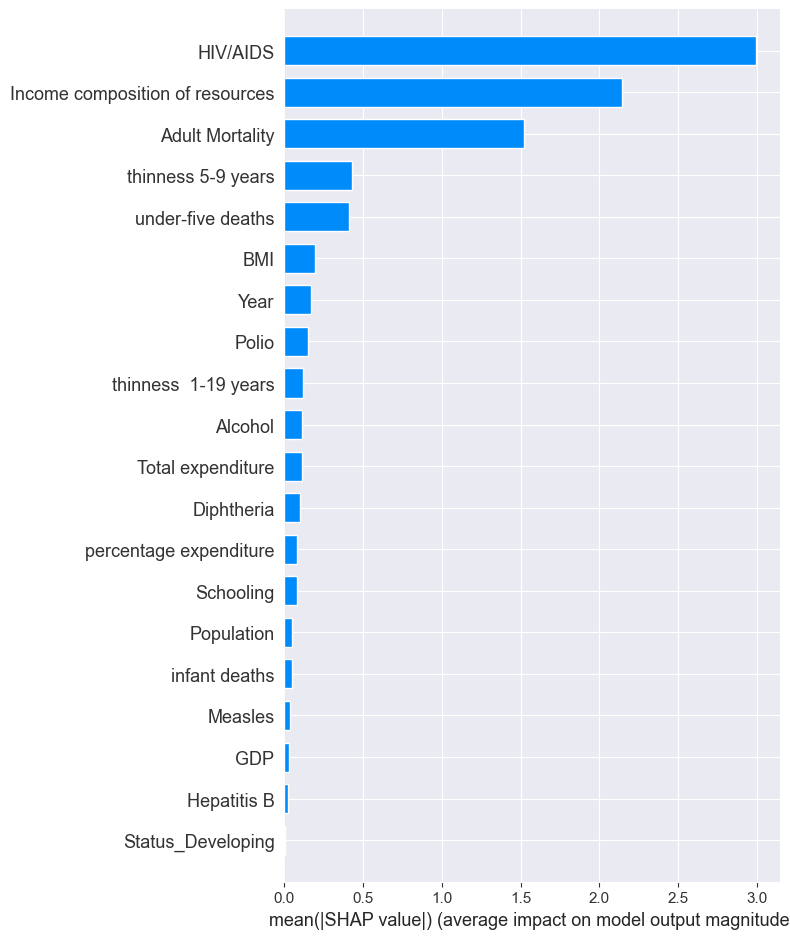

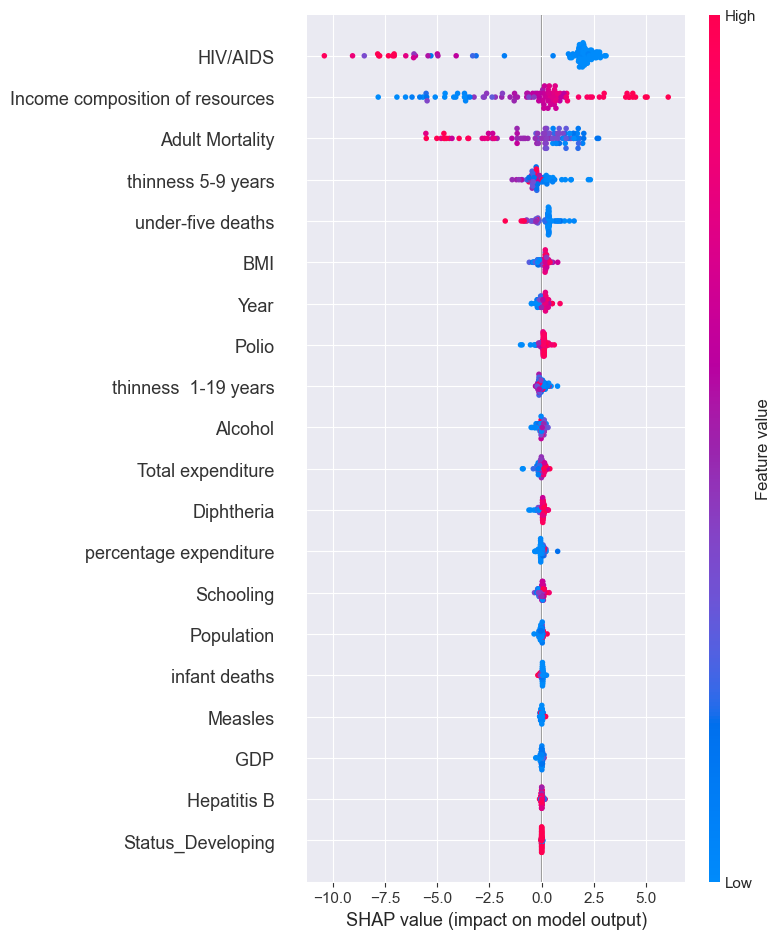

In [39]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type="bar")

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap)

### 4.6.2. Analiza Locală SHAP: Interpretarea unei Predicții Individuale

Pentru a înțelege cum ajunge modelul la o anumită cifră pentru o observație specifică, am analizat prima instanță din setul de test (`sample_idx = 0`). Această abordare ne permite să vedem „mecanismul” intern al deciziei pentru un caz concret.

---

### A. Waterfall Plot (Descompunerea Predicției)

**Ce reprezintă:**
Acest grafic pornește de la valoarea de bază (media tuturor predicțiilor, $E[f(X)]$) și adaugă sau scade contribuția fiecărei variabile pentru a ajunge la valoarea finală prezisă $f(x)$.

---

### Interpretarea rezultatelor:

- **Săgețile roșii (valori pozitive):**
  Reprezintă caracteristicile care au crescut speranța de viață pentru această țară/instanță. De exemplu, un nivel ridicat de **Schooling** sau un **BMI** optim pot „împinge” rezultatul în sus.

- **Săgețile albastre (valori negative):**
  Reprezintă factorii care au penalizat scorul. O valoare mare pentru **Adult Mortality** sau **HIV/AIDS** acționează ca o forță de scădere asupra rezultatului final.

---

### Concluzie locală:

Putem observa exact care a fost cel mai influent factor pentru acest eșantion, oferind o explicație clară și transparentă (de exemplu: *„Speranța de viață este de 72 de ani deoarece nivelul de educație a compensat rata mortalității adulte”*).

---

### B. Force Plot (Echilibrul Forțelor)

**Ce reprezintă:**
Este o vizualizare alternativă a acelorași date, concepută ca un „joc de tras frânghia” între variabile.

---

### Detalii vizuale:

- **Zona Roșie (left side):**
  Caracteristicile care exercită presiune pentru a crește valoarea predicției.

- **Zona Albastră (right side):**
  Caracteristicile care exercită presiune pentru a scădea valoarea predicției.

- **Punctul de întâlnire:**
  Reprezintă valoarea finală prezisă ($f(x)$). Lungimea segmentului fiecărei variabile indică magnitudinea influenței sale.

---

### Utilitate:

Force Plot-ul este extrem de util pentru a vizualiza rapid dacă o predicție este rezultatul unui consens între variabile sau dacă există un conflict major între factorii pozitivi și cei negativi.

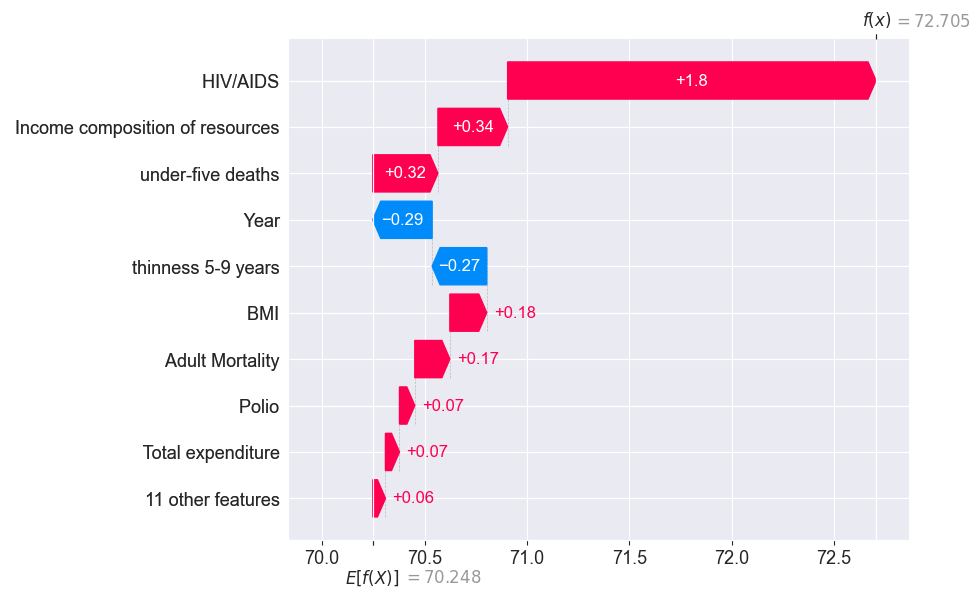

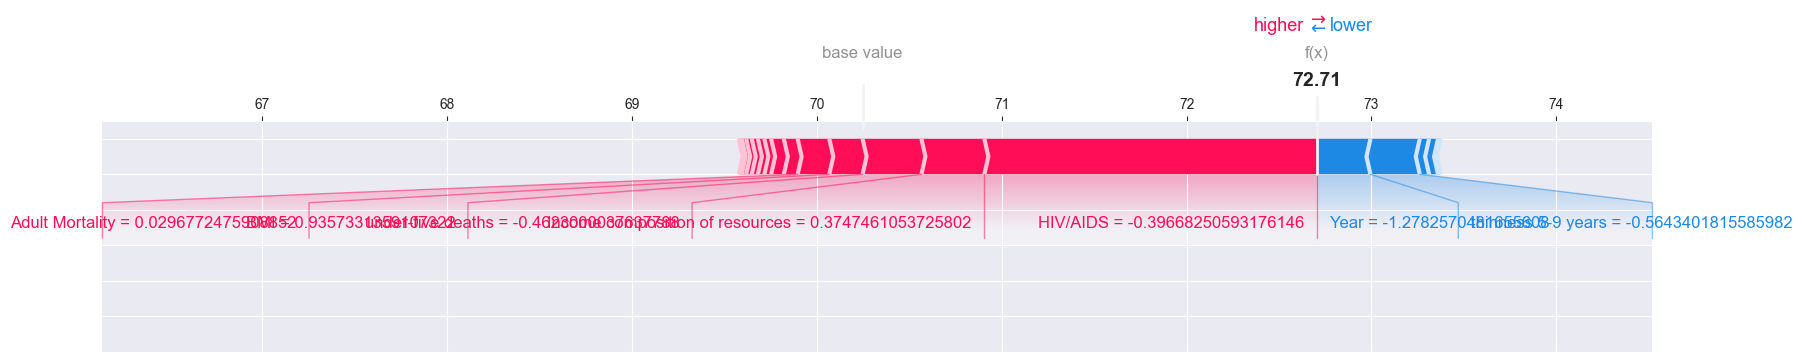

In [45]:
sample_idx = 0
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[0]

plt.figure(figsize=(10, 6))
shap.plots._waterfall.waterfall_legacy(
    base_value,
    shap_values[sample_idx],
    X_shap.iloc[sample_idx]
)

shap.force_plot(
    base_value,
    shap_values[sample_idx],
    X_shap.iloc[sample_idx],
    matplotlib=True
)

### 4.6.3. Analiza Dependenței: Cum Influențează Valorile Specifice Predicția

Spre deosebire de analizele anterioare, SHAP Dependence Plots ne permit să observăm relația directă și adesea non-liniară dintre valoarea unei variabile și impactul său asupra speranței de viață. Am ales cele mai relevante 3 caracteristici pentru a evidenția modul în care acestea „împing” predicțiile în sus sau în jos.

---

### 1. Analiza Caracteristicii: Schooling (Educația)

**Comportament:**
Se observă o tendință clară pozitivă. Pe măsură ce anii de școlarizare cresc (axa X), valoarea SHAP trece din zona negativă în cea pozitivă (axa Y).

**Impact:**
- **Valorile mici (sub 10 ani):**
  Tind să tragă predicția în jos, având un impact negativ asupra speranței de viață.
- **Valorile mari (peste 13–15 ani):**
  Contribuie semnificativ la creșterea predicției.

**Concluzie:**
Educația acționează ca un accelerator al longevității, impactul său devenind exponențial mai puternic după pragul învățământului secundar.

---

### 2. Analiza Caracteristicii: HIV/AIDS

**Comportament:**
Relația este invers proporțională și extrem de agresivă.

**Impact:**
- **Valorile mici (apropiate de 0):**
  Au un impact neutru sau ușor pozitiv (nu penalizează modelul).
- **Valorile mari:**
  Imediat ce prevalența crește, valorile SHAP „cad” brusc în zona negativă.

**Concluzie:**
Această variabilă funcționează ca un „penalizator radical”. Chiar și o creștere moderată a prevalenței HIV/SIDA este suficientă pentru a prăbuși speranța de viață prezisă, indiferent de ceilalți factori.

---

### 3. Analiza Caracteristicii: Adult Mortality (Mortalitatea Adulților)

**Comportament:**
O corelație negativă liniară aproape perfectă.

**Impact:**
- **Punctele din stânga (valori mici ale mortalității):**
  Corespund unor valori SHAP pozitive ridicate.
- **Punctele din dreapta (mortalitate mare):**
  Sunt asociate cu valori SHAP negative.

**Concluzie:**
Modelul identifică mortalitatea adulților ca fiind cel mai stabil indicator al stării de sănătate. Scăderea mortalității adulte „împinge” constant predicția în sus, fiind un motor principal al creșterii speranței de viață în modelul nostru.

<Figure size 800x500 with 0 Axes>

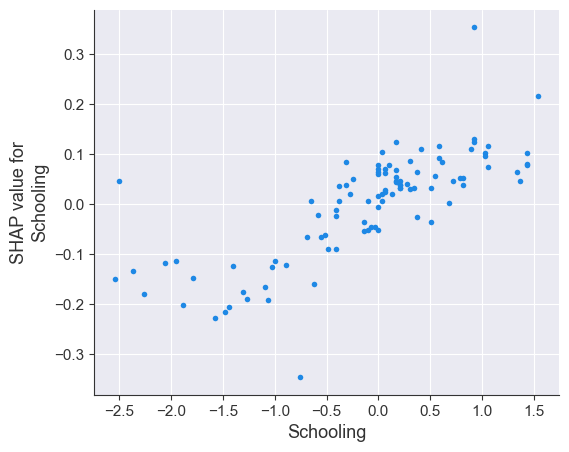

<Figure size 800x500 with 0 Axes>

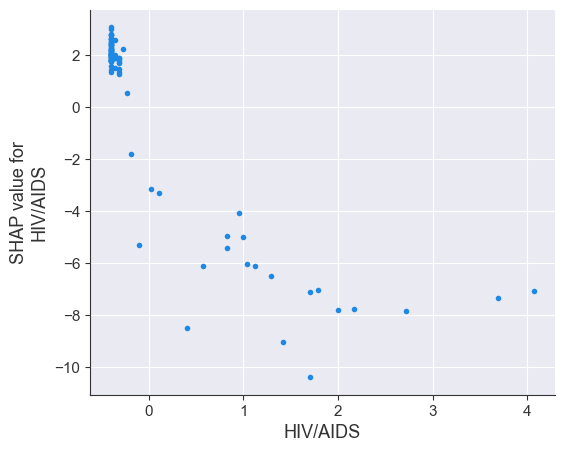

<Figure size 800x500 with 0 Axes>

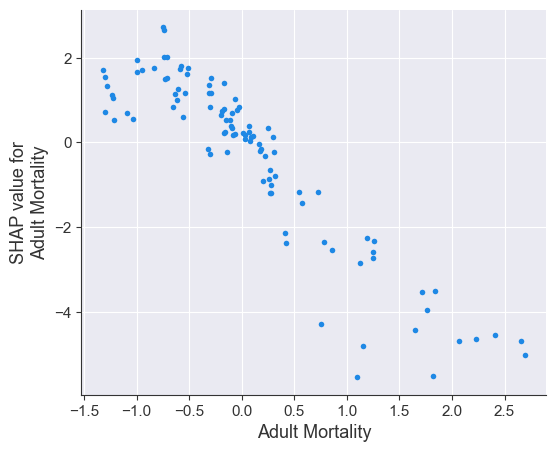

In [41]:
features_to_plot = ['Schooling', 'HIV/AIDS', 'Adult Mortality']

for feature in features_to_plot:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(feature, shap_values, X_shap, interaction_index=None)

### 4.6.4. Analiza SHAP pentru XGBoost Regressor

Pentru a asigura robustețea concluziilor noastre, am realizat o analiză SHAP completă și pentru al doilea cel mai bun model identificat în etapa de tuning, și anume **XGBoost Regressor**. Deși arhitecturile pot diferi, se observă o consistență remarcabilă în modul în care variabilele influențează predicțiile, consolidând încrederea în factorii determinanți identificați.

---

### A. Importanța Globală (Bar Plot & Summary Plot)

**Consistența rezultatelor:**
Similar cu modelul anterior, ierarhia importanței caracteristicilor rămâne stabilă.

**Top predictori:**
- **HIV/AIDS** continuă să fie cel mai critic factor de impact negativ.
- **Income composition of resources** și **Adult Mortality** își mențin pozițiile de predictori dominanți, confirmând că motorul principal al speranței de viață este un mix între sănătatea publică și resursele economice.

**Distribuția impactului:**
Summary plot-ul evidențiază aceleași tipare:
- Valorile ridicate ale resurselor financiare și educației (*puncte roșii*) se grupează în zona de impact pozitiv.
- Mortalitatea ridicată și prevalența HIV trag predicția în jos.

---

### B. Analiza Dependenței și Explicații Locale

**Relații non-liniare:**
Graficele de tip scatter (*Dependence Plots*) pentru acest model confirmă pragurile identificate anterior. Impactul educației devine semnificativ după un anumit număr de ani, iar penalizarea pentru mortalitate adultă urmează aceeași pantă descendentă constantă.

---

### Waterfall & Force Plot (Local)

Analizând aceeași instanță (`sample_idx = 0`), observăm că modelul **XGBoost Regressor** ajunge la o predicție foarte apropiată de primul model, utilizând ponderi aproape identice pentru variabilele cheie.

Acest nivel de aliniere între modele diferite (de exemplu, între un model de tip boosting și unul de tip Random Forest) sugerează că semnalul din date este foarte puternic și clar interpretat de algoritmi.

---

### Concluzie Inter-Model

Faptul că primele două modele plasează aceleași 3 variabile (**HIV/AIDS**, **Income composition of resources**, **Adult Mortality**) în vârful piramidei de decizie demonstrează că am obținut un model nu doar precis, ci și fundamentat pe factori biologici și socio-economici reali și reproductibili.

Generăm analiza SHAP completă pentru cel mai bun model: XGBoost Regressor


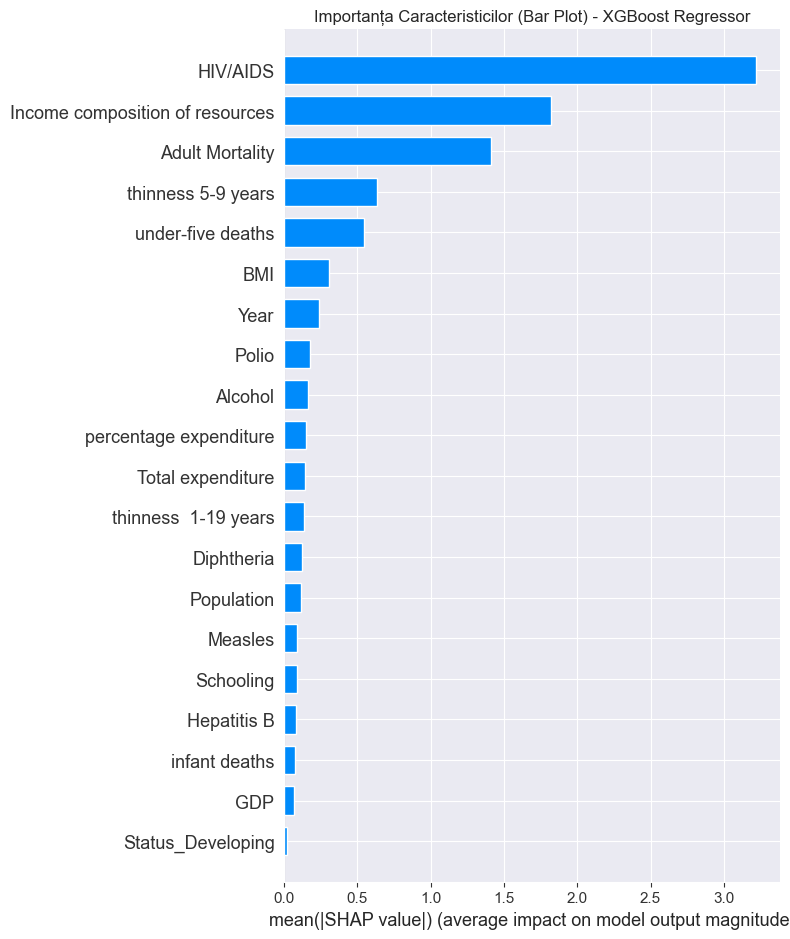

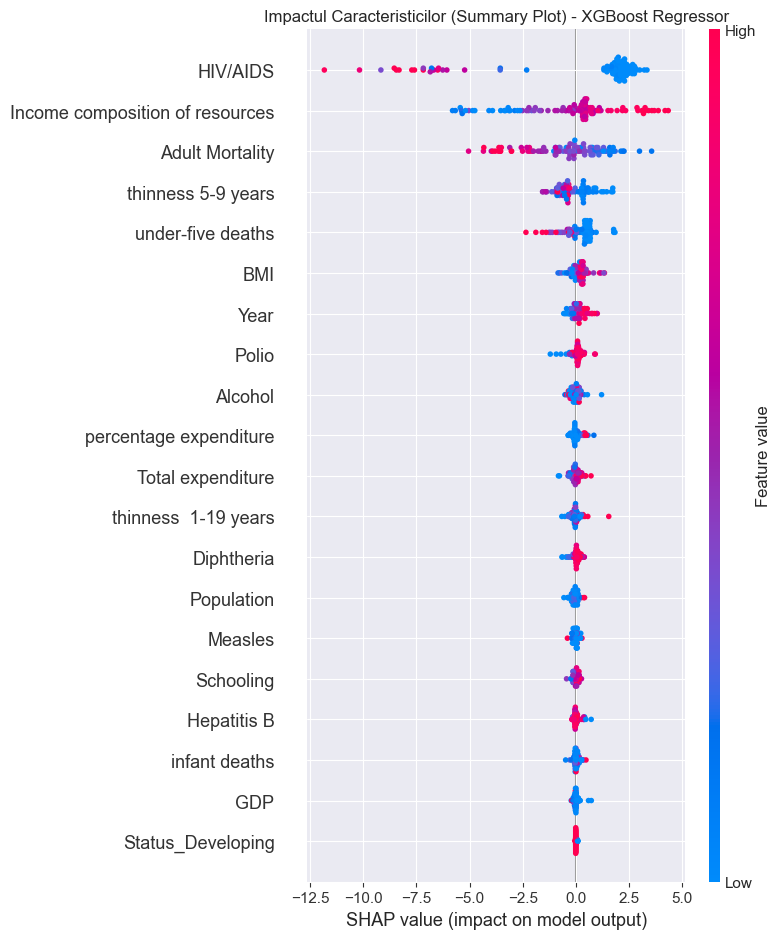

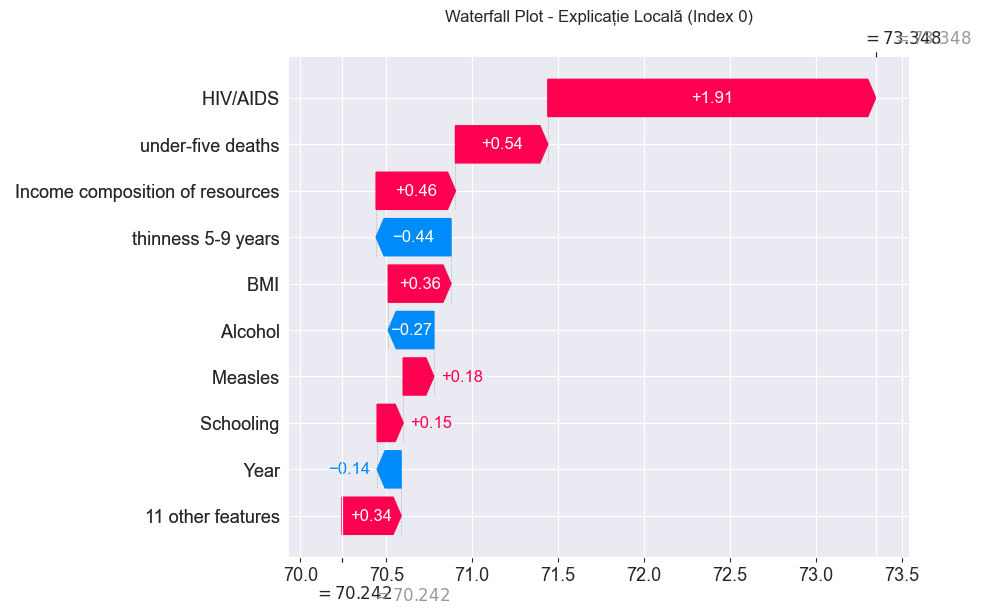

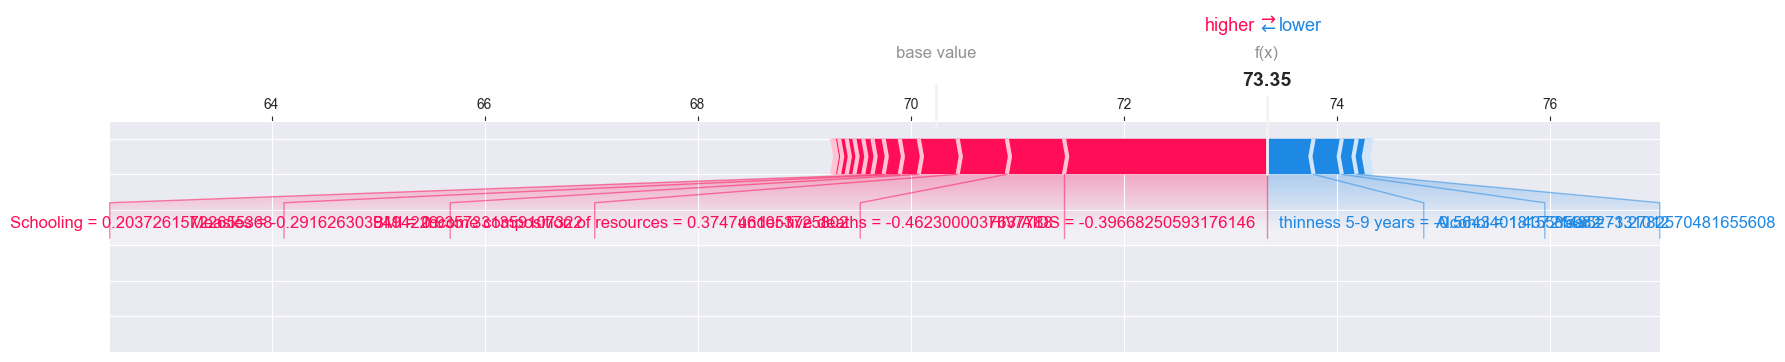

None

In [47]:
import shap
import matplotlib.pyplot as plt
import numpy as np

best_model_name = tuned_df['Model'].iloc[1]
model_to_explain = best_estimators[best_model_name]
print(f"Generăm analiza SHAP completă pentru cel mai bun model: {best_model_name}")

X_shap = X_test.iloc[:100]
explainer = shap.TreeExplainer(model_to_explain)
raw_shap_values = explainer.shap_values(X_shap)

if isinstance(raw_shap_values, list):
    shap_v = raw_shap_values[1]
    expected_v = explainer.expected_value[1]
else:
    shap_v = raw_shap_values
    expected_v = explainer.expected_value

if isinstance(expected_v, (list, np.ndarray)):
    expected_v = expected_v[0]

plt.figure(figsize=(10, 6))
plt.title(f"Importanța Caracteristicilor (Bar Plot) - {best_model_name}")
shap.summary_plot(shap_v, X_shap, plot_type="bar", show=False)
plt.show()

plt.figure(figsize=(10, 6))
plt.title(f"Impactul Caracteristicilor (Summary Plot) - {best_model_name}")
shap.summary_plot(shap_v, X_shap, show=False)
plt.show()

features_to_plot = ['city_development_index', 'experience', 'last_new_job']

for feature in features_to_plot:
    if feature in X_shap.columns:
        plt.figure(figsize=(8, 5))
        shap.dependence_plot(feature, shap_v, X_shap, interaction_index=None, show=False)
        plt.title(f"SHAP Scatter Plot: {feature}")
        plt.show()

sample_idx = 0

plt.figure(figsize=(12, 8))
shap.plots._waterfall.waterfall_legacy(expected_v, shap_v[sample_idx], X_shap.iloc[sample_idx], show=False)
plt.title(f"Waterfall Plot - Explicație Locală (Index {sample_idx})")
plt.show()

shap.initjs()
display(shap.force_plot(expected_v, shap_v[sample_idx], X_shap.iloc[sample_idx], matplotlib=True))

### 4.6.4. Analiza SHAP pentru CatBoost Regressor

Pentru a valida rezultatele obținute, am aplicat analiza SHAP asupra modelului  **CatBoost Regressor**. Aceasta confirmă consistența și relevanța variabilelor identificate.

---

### A. Importanța Globală

Atât bar plot-ul, cât și summary plot-ul evidențiază aceiași predictori principali:

- **HIV/AIDS** – factorul cu cel mai puternic impact negativ
- **Income composition of resources** și **Adult Mortality** – factori dominanți care reflectă influența combinată a condițiilor economice și a sănătății publice

Valorile mari ale resurselor și educației cresc predicția, în timp ce mortalitatea ridicată și prevalența HIV o reduc.

---

### B. Analiza Dependenței și Locală

Graficele de dependență confirmă relațiile observate anterior:
- educația are un impact pozitiv după un anumit prag,
- mortalitatea și HIV reduc consistent speranța de viață.

Analiza locală (*Waterfall* și *Force Plot*) arată cum fiecare variabilă contribuie la predicția finală pentru un caz concret, evidențiind echilibrul dintre factorii pozitivi și negativi.


Generăm analiza SHAP completă pentru cel mai bun model: CatBoost Regressor


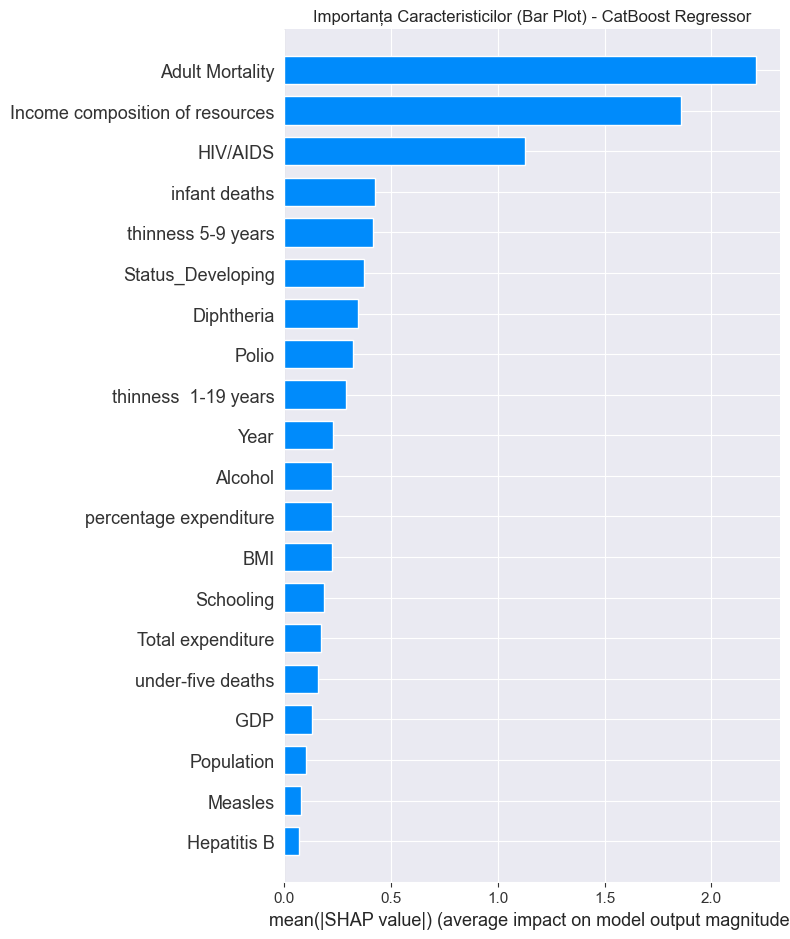

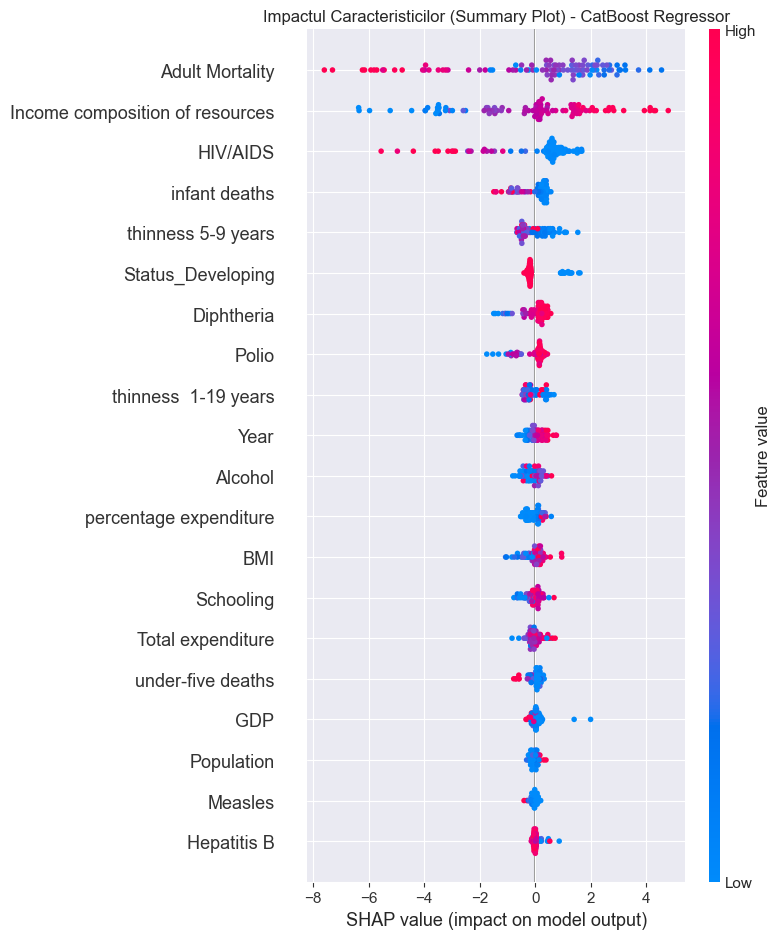

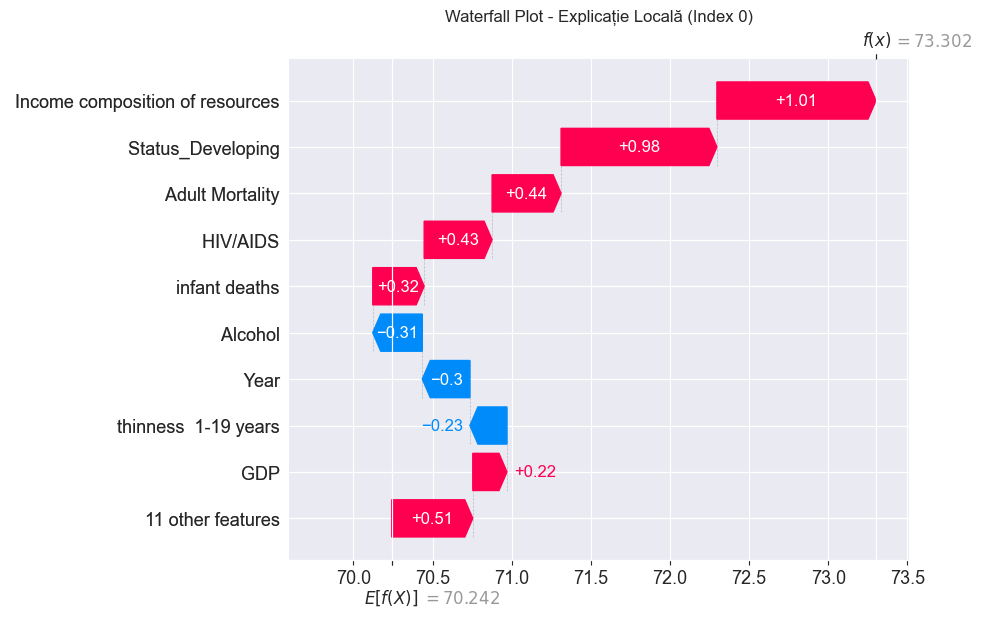

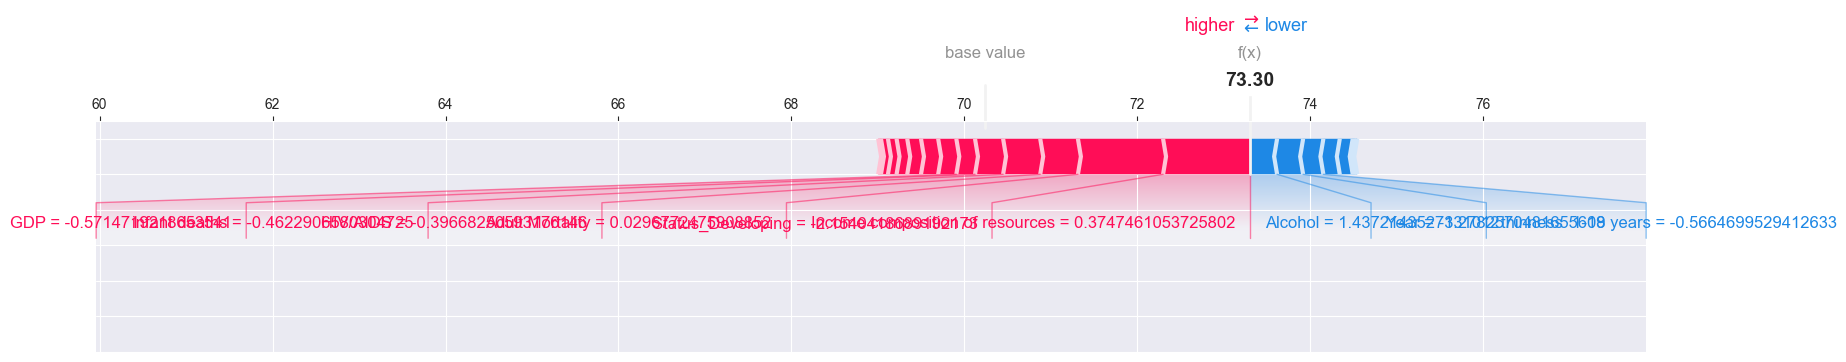

None

In [49]:
import shap
import matplotlib.pyplot as plt
import numpy as np

best_model_name = tuned_df['Model'].iloc[2]
model_to_explain = best_estimators[best_model_name]
print(f"Generăm analiza SHAP completă pentru cel mai bun model: {best_model_name}")

X_shap = X_test.iloc[:100]
explainer = shap.TreeExplainer(model_to_explain)
raw_shap_values = explainer.shap_values(X_shap)

if isinstance(raw_shap_values, list):
    shap_v = raw_shap_values[1]
    expected_v = explainer.expected_value[1]
else:
    shap_v = raw_shap_values
    expected_v = explainer.expected_value

if isinstance(expected_v, (list, np.ndarray)):
    expected_v = expected_v[0]

plt.figure(figsize=(10, 6))
plt.title(f"Importanța Caracteristicilor (Bar Plot) - {best_model_name}")
shap.summary_plot(shap_v, X_shap, plot_type="bar", show=False)
plt.show()

plt.figure(figsize=(10, 6))
plt.title(f"Impactul Caracteristicilor (Summary Plot) - {best_model_name}")
shap.summary_plot(shap_v, X_shap, show=False)
plt.show()

features_to_plot = ['city_development_index', 'experience', 'last_new_job']

for feature in features_to_plot:
    if feature in X_shap.columns:
        plt.figure(figsize=(8, 5))
        shap.dependence_plot(feature, shap_v, X_shap, interaction_index=None, show=False)
        plt.title(f"SHAP Scatter Plot: {feature}")
        plt.show()

sample_idx = 0

plt.figure(figsize=(12, 8))
shap.plots._waterfall.waterfall_legacy(expected_v, shap_v[sample_idx], X_shap.iloc[sample_idx], show=False)
plt.title(f"Waterfall Plot - Explicație Locală (Index {sample_idx})")
plt.show()

shap.initjs()
display(shap.force_plot(expected_v, shap_v[sample_idx], X_shap.iloc[sample_idx], matplotlib=True))